# Evaluation of baseline model fits

In [38]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sc = "all"
norm = "zscore"

#-------------------

gams_cluster_order = ["SD", "SU", "DSU", "N/A"]
gams_cluster_names = {0 : "SD", 1:"SU", 2:"DSU", 3: "SU", 4: "DSU", np.nan: "N/A"}

p_cluster_order = ["SD", "TU", "SU", "DSU", "N/A"]
p_cluster_names = {0:"SD", 1: "TU",2: "SU", 3: "DSU", 4:"SU", np.nan: "N/A"}

col_c = sns.color_palette("Set1", n_colors=8)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], "TU": "gold", 
                      "pre-ZGA SU": "lightgreen", "TD-SU": col_c[4], "TU-SD": col_c[7], "TU-DSD": col_c[6], 
                      "N/A":"lightgray"}

model_map = {"Z": "Z-decay", "M": "M-decay"}

col_m = sns.color_palette("Dark2")  
model_name_map = {"Basic":"Basic", "Rep_M":"M-decay", "Rep_Z":"Z-decay",}
mod_color_dict = {"Basic": col_m[7],"M-decay": col_m[1], "Z-decay": col_m[4] } 
#model_order = ["Basic", "Rep_M", "Rep_Z"]
model_order = ["Basic", "M-decay", "Z-decay"]

col_s = sns.color_palette("twilight_shifted")  
src_color_dict =  {'White':col_s[0], 'Pauli':col_s[1], 'JN':col_s[4], 'BK':col_s[5]}

subcluster_color_map = {"TU-DSD":sns.color_palette("copper", 3),
             "TD-SU":sns.color_palette("Oranges_r", 3),
             "SU":sns.color_palette("Greens_d", 3),
             "TU":sns.color_palette("RdPu_r", 6),
             "SD":sns.color_palette("Reds_d", 4),
             "DSD":sns.color_palette("Blues_d", 4),
             "DSU":sns.color_palette("Purples_d",4),
            }

#--------------------------------

r_hat_thresh = 1.05
NRMSE_thresh = 0.25
ESS_thresh = 400        # ESS: 100 per chain
r2_thresh = 0.7
rho_tresh = 0.5

status_dict = {
    "non_con":f"Not converged",
    "poor_fit": f"Poor fit\n(NRMSE>{NRMSE_thresh}, ρ<{rho_tresh})",
    "pattern":f"Qualitative\npattern reproduction\n(NRMSE>{NRMSE_thresh}, ρ≥{rho_tresh})",
    "low_error":  f"Quantitative good fit\n(NRMSE≤{NRMSE_thresh}, ρ<{rho_tresh})",
    "fully_accepted": f"Fully accepted\n(NRMSE≤{NRMSE_thresh}, ρ≥{rho_tresh})",
}

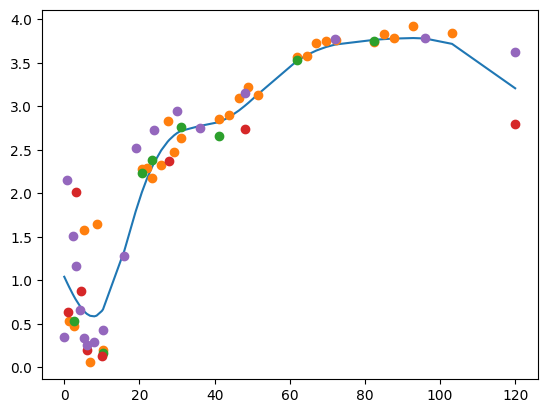

In [20]:
du = xr.load_dataarray("clustering/results/all_gene_trajectories_120_log.nc")
gene = du.ensembl_gene_id.values[1]

du=du.sel(ensembl_gene_id = gene)
obs = xr.load_dataarray("data/genes_tpms_white_pauli_JN_BK_mean.nc")
obs=obs.sel(ensembl_gene_id=gene)
obs = np.log2(obs+1)

plt.plot(du.time, du)
plt.plot(obs.time, obs, "o")

## Join evaluation scorecards

In [39]:
res_z = pd.read_csv("results/results_summary/Rep_Z/fit_scorecard_flagged.csv")  # 29308 genes
res_m = pd.read_csv("results/results_summary/Rep_M/fit_scorecard_flagged.csv")  # 29308 
res_b = pd.read_csv("results/results_summary/Basic/fit_scorecard_flagged.csv")  # 29308

cluster = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
genes = cluster.ensembl_gene_id.values 
genes_total = res_z.gene.values

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": cluster["ensembl_gene_id"].values,
    "supercluster_no": cluster["supercluster"].values,
    "subcluster_no": cluster["subcluster"].values,
}).set_index("ensembl_gene_id")
lookup["supercluster"]=lookup["supercluster_no"].map(gams_cluster_names)

# Map onto df by gene_id
for df in [res_b, res_z, res_m]:
    df["supercluster"] = df["gene"].map(lookup["supercluster"]).fillna("N/A")
    df["subcluster"] = df["gene"].map(lookup["subcluster_no"]).fillna("N/A")

# res_b = res_b[res_b.gene.isin(genes)].copy()
# res_z = res_z[res_z.gene.isin(genes)].copy()
# res_m = res_m[res_m.gene.isin(genes)].copy()

res_b.loc[:, "model"] = "Basic"
res_z.loc[:, "model"] = "Rep_Z"
res_m.loc[:, "model"] = "Rep_M"

res = pd.concat([res_b, res_z, res_m], axis=0, ignore_index=True)
res = res.rename(columns={"gene":"gene_id",})

gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof1 = gof[["gene_id", "model", "NRMSE", "BIC"]]
gof1 = gof1.set_index(["gene_id", "model"])

res1 = res.set_index(["gene_id", "model"])
res_joined = res1.join(gof1, on=["gene_id", "model"], how="left").reset_index()

# flags
res_joined["good_fit_r2"] = res_joined["r2"] >= r2_thresh
res_joined["good_fit"] = res_joined["NRMSE"] <= NRMSE_thresh
res_joined["converged"] = ((res_joined["rhat_max"] <= r_hat_thresh) & (res_joined["ess_bulk_min"] >= ESS_thresh)) # & (res_joined["n_divergences"] == 0) )
res_joined["well_calibrated"] = res_joined["pp_coverage_90"].between(0.80, 0.98)
res_joined["pattern_reproduction"] = res_joined["pearson_r"] >= rho_tresh 
res_joined["pattern_reproduction_rho"] = res_joined["spearman_rho"] >= rho_tresh


import numpy as np

# conditions = [
#     ~res_joined["converged"],
#     res_joined["converged"] & ~res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
#     res_joined["converged"] & ~res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
#     res_joined["converged"] & res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
#     res_joined["converged"] & res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
# ]

# choices = [
#     "non_con",
#     "poor_fit",
#     "pattern",
#     "low_error",
#     "fully_accepted",
# ]

conditions = [
    ~res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
    ~res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
    res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
    res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
]

choices = [
    "poor_fit",
    "pattern",
    "low_error",
    "fully_accepted",
]

res_joined["model"] = res_joined["model"].map(model_name_map)
res_joined["status"] = np.select(conditions, choices)

# accepted model fits (REP)
#gof = res_joined[res_joined["status"] == "fully_accepted"]
gof = res_joined[res_joined["status"] != "poor_fit"]
genes_acc = np.unique(gof[gof["model"] != "Basic"]["gene_id"])  ## accepted by at lest one model (M / Z decay)
pd.DataFrame({"gene_id":genes_acc}).to_csv("acc_genes.csv", index=False)

print(genes_acc.size, "; ", round(genes_acc.size/genes_total.size * 100, 2),"%")

res_joined.to_csv("model_fit_evaluation.csv", index=False)
res_joined

26957 ;  91.98 %


,gene_id,model,rhat_max,ess_bulk_min,ess_tail_min,convergence_error,n_divergences,frac_divergences,loo,loo_se,...,reliable_loo,well_calibrated,status,supercluster,subcluster,NRMSE,BIC,good_fit,pattern_reproduction,pattern_reproduction_rho
0,ENSDARG00000000018,Basic,1.000000,6808.000000,4829.000000,NaN,0,0.000000,-50.956989,8.697937,...,True,True,poor_fit,SD,1.0,0.304176,110.662477,False,False,False
1,ENSDARG00000000019,Basic,1.000000,7701.000000,4765.000000,NaN,0,0.000000,-5.719403,5.559465,...,True,True,low_error,SD,0.0,0.213511,20.958594,True,True,False
2,ENSDARG00000000068,Basic,1.000000,6869.000000,4900.000000,NaN,0,0.000000,-61.596542,5.332585,...,True,True,poor_fit,SD,0.0,0.299493,133.565563,False,True,False
3,ENSDARG00000000069,Basic,1.000000,7276.000000,4974.000000,NaN,0,0.000000,-13.211758,6.442222,...,True,True,fully_accepted,SD,0.0,0.133944,33.844029,True,True,True
4,ENSDARG00000000001,Basic,1.000000,7587.000000,5176.000000,NaN,0,0.000000,-47.368093,13.946546,...,False,True,low_error,SD,0.0,0.247397,101.364765,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87919,ENSDARG00000117784,M-decay,1.000743,9821.843331,5370.671841,NaN,0,0.000000,67.105043,7.911655,...,True,True,poor_fit,DSU,0.0,0.252044,-110.287701,False,True,False
87920,ENSDARG00000117806,M-decay,1.000735,6614.776418,4011.936600,NaN,0,0.000000,26.642192,13.896285,...,False,True,low_error,SU,1.0,0.167096,-37.566268,True,True,False
87921,ENSDARG00000117816,M-decay,1.000531,9410.349648,5323.865046,NaN,0,0.000000,2.228591,7.088810,...,True,True,poor_fit,SD,1.0,0.310569,18.507317,False,False,False
87922,ENSDARG00000117822,M-decay,1.000788,7226.409953,2816.916598,NaN,0,0.000000,-8.549709,6.055127,...,True,True,poor_fit,SD,1.0,0.310686,39.577781,False,False,False


In [219]:
non_cov = res_joined[(res_joined["converged"]==False) & (res_joined["model"]=="M-decay") ].gene_id
print(len(non_cov))

with open("non_conv_m.txt", "w") as f:
    for line in non_cov:
        f.write(f"{line}\n")

non_cov = res_joined[(res_joined["converged"]==False) & (res_joined["model"]=="Z-decay") ].gene_id
print(len(non_cov))

with open("non_conv_z.txt", "w") as f:
    for line in non_cov:
        f.write(f"{line}\n")

2510
2043


<Axes: title={'center': 'GOF summary by model (n = 29,308 genes)'}, xlabel='Proportion of genes'>

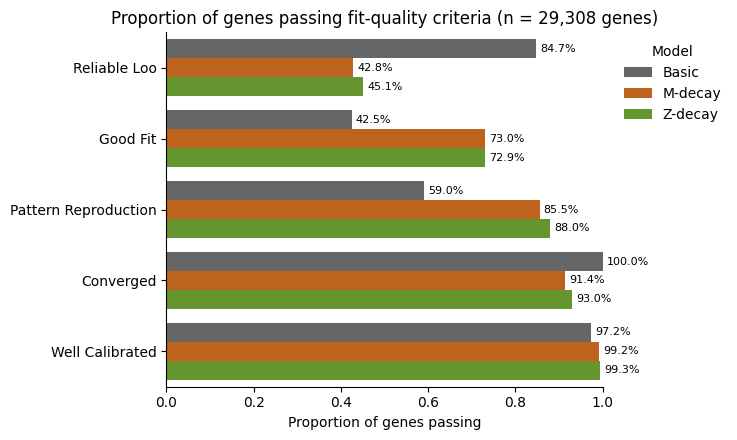

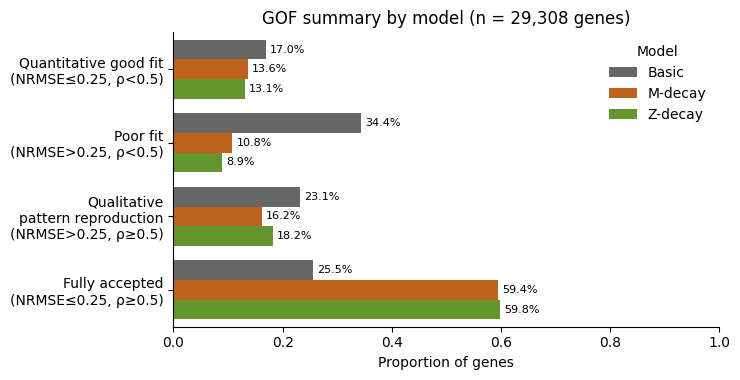

In [142]:
from plots.plot_scorecard_summary import *
res_plot = res_joined.reset_index()
plot_pass_rates(res_plot, hue="model")
plot_status_breakdown(df=res_plot, status_dict=status_dict, hue="model")

In [ ]:
from plots.plot_scorecard_summary import *
res_plot = res_joined.reset_index()

for m in res_plot.model.unique():
    res1 = res_plot[res_plot["model"] == m].copy()
    plot_pass_rates(res1, hue="supercluster", title=m)
    plot_status_breakdown(res1, status_dict=status_dict, hue="supercluster", title=m)

### Heatmap accepted - GAMS

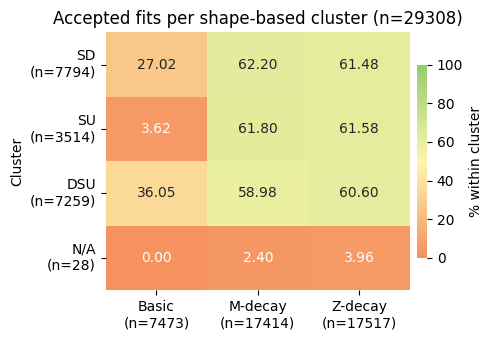

In [40]:
# accepted fit heatmap
res_plot = res_joined.reset_index()
accepted = res_plot[res_plot["status"] == "fully_accepted"][["gene_id", "model", "supercluster", "status"]]

count_model = accepted["model"].value_counts()
count_cluster = accepted.groupby("supercluster")["gene_id"].nunique()

merged_counts = res_plot.groupby(["model", "supercluster"]).size().reset_index(name="merged")
accepted_counts = accepted.groupby(["model", "supercluster"]).size().reset_index(name="accepted")
result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "supercluster"])

result["accepted"] = result["accepted"].fillna(0).astype(int)
result["ratio"] = result["accepted"] / result["merged"] * 100

# Pivot for heatmap
pivot = result.pivot(index="supercluster", columns="model", values="ratio") 
pivot = pivot.reindex(index=gams_cluster_order, columns=model_order)

fig, ax = plt.subplots(figsize=(5,3.5))
sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
            cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': '% within cluster', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)


ax.set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
ax.set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

ax.set(xlabel="", title=f"Accepted fits per shape-based cluster (n={res_plot.gene_id.nunique()})", ylabel="Cluster")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"results/figures/accepted_heatmap_gof.png", dpi=300)
plt.show()

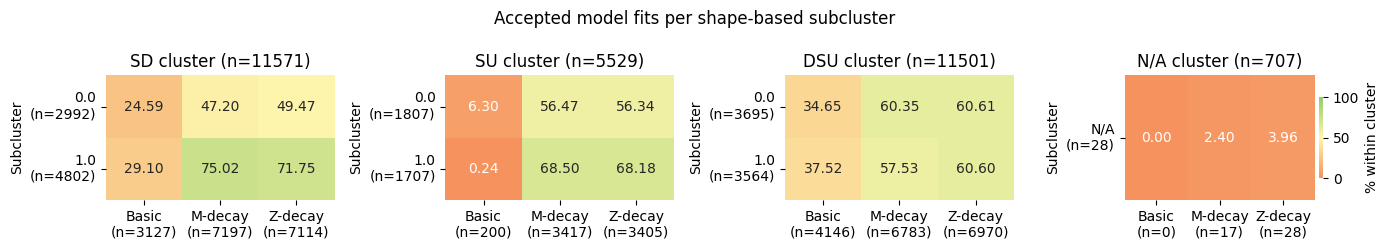

In [90]:
# accepted fit heatmap per subcluster
plot = res_joined.copy()
n_panels = len(gams_cluster_order)


fig, ax = plt.subplots(1,n_panels, figsize=(3.5*n_panels, 2.5), sharey=False)
ax=ax.flatten()

for x, i in enumerate(gams_cluster_order):

    d = plot[plot["supercluster"] == i]

    accepted = d[d["status"] == "fully_accepted"][["gene_id", "model", "supercluster", "subcluster", "status"]]

    count_model = accepted["model"].value_counts()
    count_cluster = accepted.groupby("subcluster")["gene_id"].nunique()

    merged_counts = d.groupby(["model", "subcluster"]).size().reset_index(name="merged")
    accepted_counts = accepted.groupby(["model", "subcluster"]).size().reset_index(name="accepted")
    result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "subcluster"])

    result["accepted"] = result["accepted"].fillna(0).astype(int)
    result["ratio"] = result["accepted"] / result["merged"] * 100

    # Pivot for heatmap
    pivot = result.pivot(index="subcluster", columns="model", values="ratio") 
    pivot = pivot.reindex(columns=model_order)

    is_last = (x == n_panels - 1)


    sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
                cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True), cbar=is_last,
                cbar_kws={'label': '% within cluster', 'shrink': 0.65, 'pad': 0.02 }, alpha=0.8, ax=ax[x] )

    ax[x].set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
    ax[x].set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

    ax[x].set(xlabel="", title=f"{i} cluster (n={d.gene_id.nunique()})", ylabel="Subcluster")
    plt.yticks(rotation=0)

plt.suptitle("Accepted model fits per shape-based subcluster")
plt.tight_layout()
plt.savefig(f"results/figures/accepted_heatmap_gof_subcluster.png", dpi=300)
plt.show()

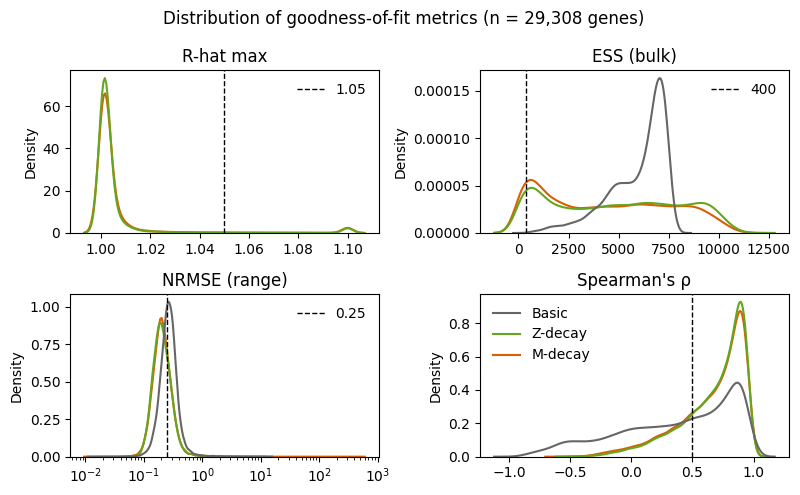

In [51]:
# GOF distribution: all model fits
d = res_joined.reset_index()  #[(res["nrmse_mean"] < 100) & (res["r2"] > 0.1)].copy()
d1 = res_joined[res_joined["model"] != "Basic"].copy()
#d1 = d1[d1["rhat_max"] < 1.05]
d1["rhat_max"] = d1["rhat_max"].clip(upper=1.1)
genes = d.gene_id.nunique()

fig, ax = plt.subplots(2,2, figsize=(8, 5))
ax = ax.flatten()

metrics=["R-hat max", "ESS (bulk)", "Max. pareto k", 
         "NRMSE (range)", "Spearman's ρ","PP Coverage", ]

metrics=["R-hat max", "ESS (bulk)", "NRMSE (range)", "Spearman's ρ",]

args = {"log_scale": True, "hue": "model", "palette": mod_color_dict, "legend": False,}

args0 = args.copy()
args0["legend"] = True

args1 = args.copy()
args1["log_scale"] = False

args2 = args1.copy()
args2["legend"] = True

sns.kdeplot(data=d1, x="rhat_max", **args2,  ax=ax[0],)
sns.kdeplot(data=d, x="ess_bulk_min", **args2,  ax=ax[1],)
#sns.kdeplot(data=d, x="max_pareto_k", ax=ax[2], **args)
ax[0].axvline(r_hat_thresh, color="black", ls="--", lw=1, label=r_hat_thresh)
ax[1].axvline(ESS_thresh, color="black", ls="--", lw=1, label=ESS_thresh)
#ax[2].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.kdeplot(data=d, x="NRMSE",ax=ax[2],**args0, cumulative=False)
sns.kdeplot(data=d, x="spearman_rho", ax=ax[3], **args2, cumulative=False)
#sns.kdeplot(data=d, x="pp_coverage_50", **args2, ax=ax[5], ls="--")
#sns.kdeplot(data=d, x="pp_coverage_90", **args2,  ax=ax[5], )

ax[2].axvline(NRMSE_thresh, color="black", ls="--", lw=1, label=NRMSE_thresh)
ax[3].axvline(rho_tresh, color="black", ls="--", lw=1, label=rho_tresh)

sns.move_legend(ax[3], loc="upper left", frameon=False, title="")
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
#ax[3].legend(frameon=False)
#ax[4].legend(frameon=False)

for i in range(len(metrics)):
    ax[i].set(title=metrics[i], xlabel="")

plt.suptitle(f"Distribution of goodness-of-fit metrics (n = {int(genes):,} genes)", fontsize=12)
plt.tight_layout()
plt.savefig(f"figures/gof_distribution.png", dpi=300)

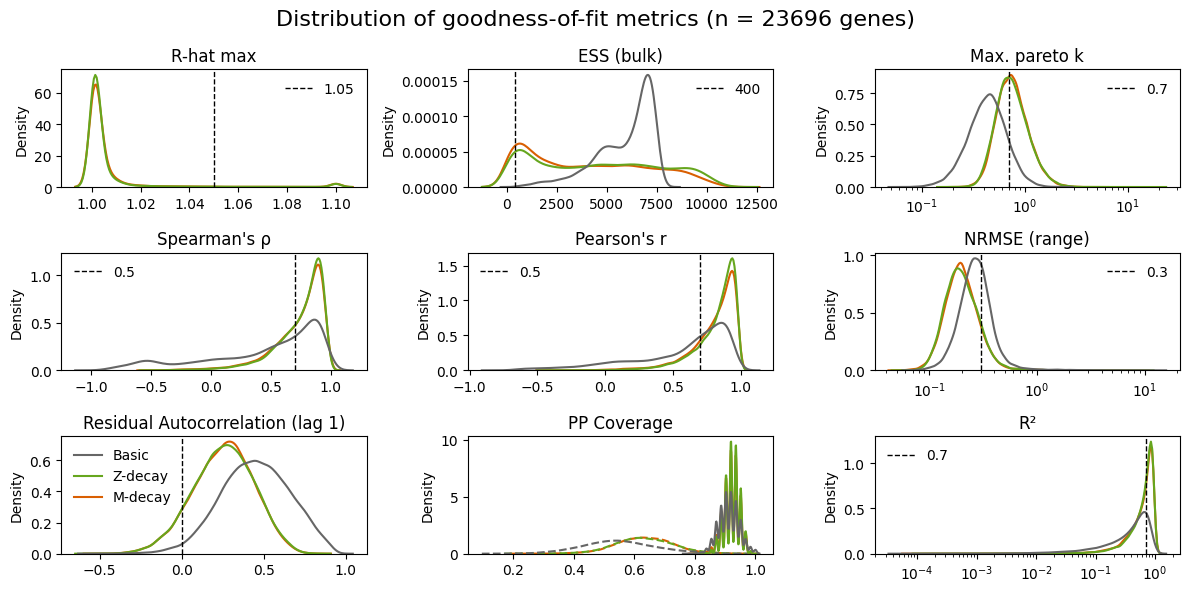

In [110]:
# GOF distribution: all model fits
d = res_joined.reset_index()  #[(res["nrmse_mean"] < 100) & (res["r2"] > 0.1)].copy()
d1 = res_joined[res_joined["model"] != "Basic"].copy()
#d1 = d1[d1["rhat_max"] < 1.05]
d1["rhat_max"] = d1["rhat_max"].clip(upper=1.1)
genes = d.gene_id.nunique()

fig, ax = plt.subplots(3,3, figsize=(12, 6))
ax = ax.flatten()

metrics=["R-hat max", "ESS (bulk)", "Max. pareto k", 
         "Spearman's ρ", "Pearson's r", "NRMSE (range)", 
         #"PMF Coverage 95%", 
         "Residual Autocorrelation (lag 1)",
         "PP Coverage", "R²", ]

args = {"log_scale": True, "hue": "model", "palette": mod_color_dict, "legend": False,}

args0 = args.copy()
args0["legend"] = True

args1 = args.copy()
args1["log_scale"] = False

args2 = args1.copy()
args2["legend"] = True

sns.kdeplot(data=d1, x="rhat_max", **args2,  ax=ax[0],)
sns.kdeplot(data=d, x="ess_bulk_min", **args2,  ax=ax[1],)
sns.kdeplot(data=d, x="max_pareto_k", ax=ax[2], **args)
ax[0].axvline(r_hat_thresh, color="black", ls="--", lw=1, label=r_hat_thresh)
ax[1].axvline(ESS_thresh, color="black", ls="--", lw=1, label=ESS_thresh)
ax[2].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.kdeplot(data=d, x="spearman_rho", ax=ax[3], **args1, cumulative=False)
sns.kdeplot(data=d, x="pearson_r", ax=ax[4], **args1, cumulative=False)
sns.kdeplot(data=d, x="NRMSE",ax=ax[5],**args0, cumulative=False)
ax[3].axvline(0.7, color="black", ls="--", lw=1, label=rho_tresh)
ax[4].axvline(0.7, color="black", ls="--", lw=1, label=rho_tresh)
ax[5].axvline(NRMSE_thresh, color="black", ls="--", lw=1, label=NRMSE_thresh)

sns.kdeplot(data=d, x="resid_autocorr_lag1", **args2, ax=ax[6])
ax[6].axvline(0, color="black", ls="--", lw=1, label="Optimum (0.0)")
#sns.kdeplot(data=d, x="pmf_coverage_95", ax=ax[6], **args2)
sns.kdeplot(data=d, x="pp_coverage_50", **args1, ax=ax[7], ls="--")
sns.kdeplot(data=d, x="pp_coverage_90", **args1,  ax=ax[7],)
sns.kdeplot(data=d, x="r2",ax=ax[8], **args)
ax[8].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.move_legend(ax[6], loc="upper left", frameon=False, title="")
ax[3].legend(frameon=False)
ax[4].legend(frameon=False)
ax[5].legend(frameon=False)
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[8].legend(frameon=False)

for i in range(len(metrics)):
    ax[i].set(title=metrics[i], xlabel="")

plt.suptitle(f"Distribution of goodness-of-fit metrics (n = {genes} genes)", fontsize=16)
plt.tight_layout()
plt.savefig(f"figures/gof_distribution_all.png", dpi=300)

## Evaluate GAMs fits

In [ ]:
import pandas as pd
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 120))
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 0.1).all(dim="source")
#ds["tpm"] = np.log(ds.tpm + 1)

traj120 = xr.load_dataarray(f"clustering/results/{sc}_gene_trajectories_120_log.nc")
gof120 = pd.read_csv("clustering/results/gof_trajectories_120.csv")
print("n genes: ",(gof120.ensembl_gene_id.nunique()))
gof120.accepted.sum()

gene_sums = gof120.groupby("ensembl_gene_id").sum("accepted")
accepted_genes = gene_sums[gene_sums["accepted"] > 0].index.to_list()
rejected_genes = gene_sums[gene_sums["accepted"] == 0].index.to_list()
print("accepted_genes by gof",len(accepted_genes))
print("rejected_genes by gof", len(rejected_genes))

labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
genes = labels.ensembl_gene_id.values
genes.sort()
print("total accepted genes, including variance", len(genes))

n genes:  29308
accepted_genes by gof 28935
rejected_genes by gof 373
total accepted genes, including variance 28601


Median NRMSE:  0.1209709181844579
Median Spearman:  0.8153101968871959


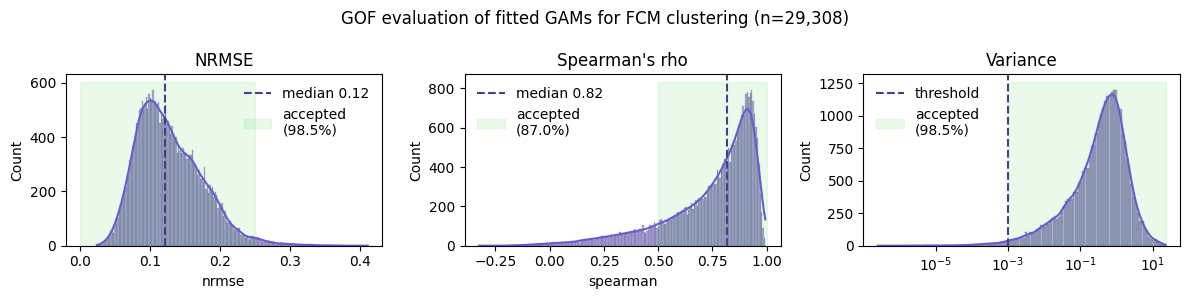

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

med_nrmse = gof120.nrmse.median().item()
med_pearson = gof120.pearson.median().item()
med_spearman = gof120.spearman.median().item()

raw_variances = np.var(traj120, axis=1)

acc_rho = len(gof120[gof120["spearman"] > rho_tresh]) / len(gof120) * 100
acc_nrmse = len(gof120[gof120["nrmse"] < NRMSE_thresh]) / len(gof120) * 100
acc_var = len(genes) / len(gof120) * 100

sns.histplot(gof120, x="spearman", log_scale=False, kde=True, ax=ax[1], bins=200,  legend=True,  color="slateblue")
sns.histplot(gof120, x="nrmse",  log_scale=False, kde=True, ax=ax[0], bins=200,  legend=False,  color="slateblue")
sns.histplot(raw_variances,  kde=True, log_scale=True, ax=ax[2], color="slateblue")

ax[1].axvline(x=med_spearman, c="darkslateblue", ls="--", label=f"median {med_spearman:.2f}")
ax[0].axvline(x=med_nrmse, c="darkslateblue", ls="--", label=f"median {med_nrmse:.2f}")
ax[2].axvline(x=0.001,  c="darkslateblue", ls="--", label="threshold")

ax[1].fill_betweenx(y=ax[1].get_ylim(), x1=rho_tresh, x2=1.0, alpha=0.1, color="limegreen", label=f"accepted\n({acc_rho:.1f}%)")
ax[0].fill_betweenx(y=ax[0].get_ylim(), x1=0.0, x2=NRMSE_thresh, alpha=0.1, color="limegreen", label=f"accepted\n({acc_nrmse:.1f}%)")
ax[2].fill_betweenx(y=ax[2].get_ylim(), x1=0.001, x2=raw_variances.max(), alpha=0.1, color="limegreen", label=f"accepted\n({acc_nrmse:.1f}%)")

ax[1].set(title="Spearman's rho", )
ax[0].set(title="NRMSE", )
ax[2].set(title="Variance", )
ax[1].legend(frameon=False)
ax[0].legend(frameon=False)
ax[2].legend(frameon=False)

plt.suptitle(f"GOF evaluation of fitted GAMs for FCM clustering (n={len(gof120):,})")
plt.tight_layout()
plt.savefig("clustering/figs/gof_eval_gams.png", dpi=300)

print("Median NRMSE: ", med_nrmse)
print("Median Spearman: ", med_spearman)

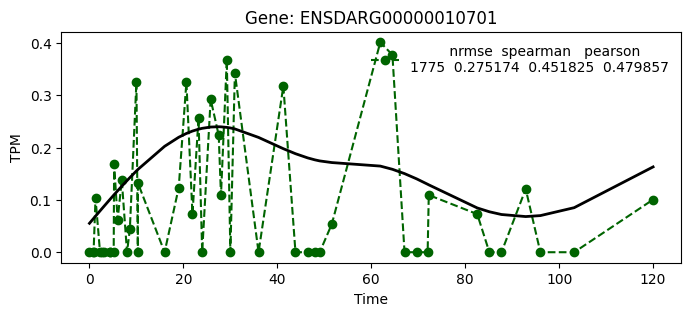

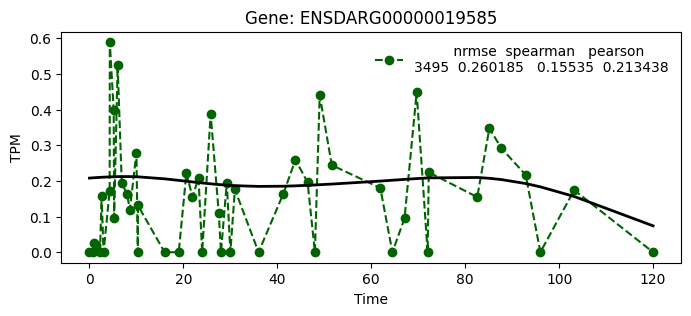

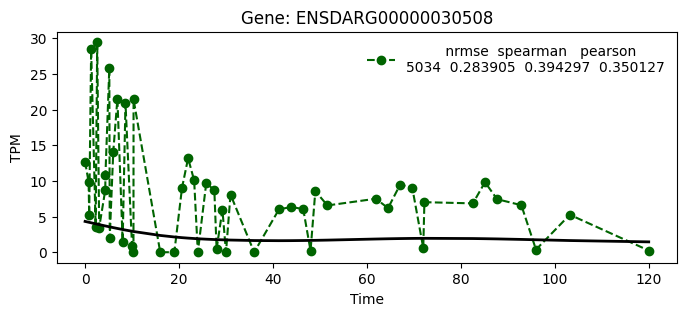

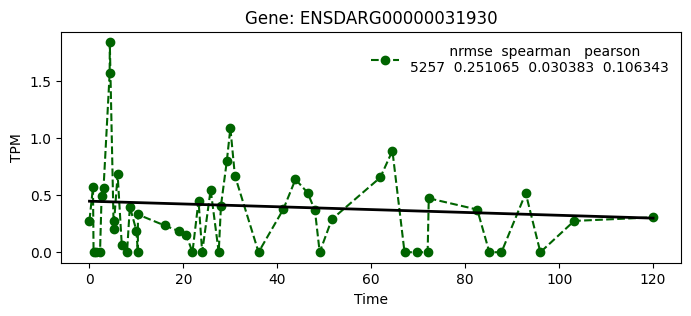

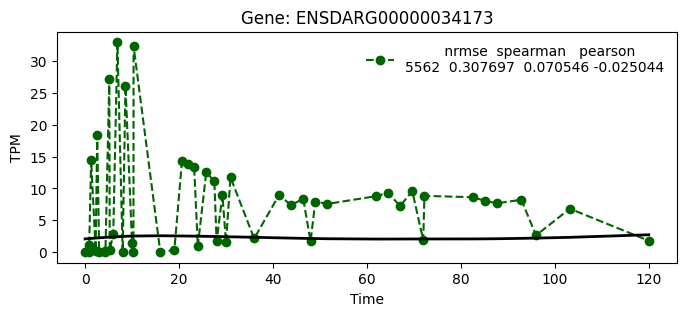

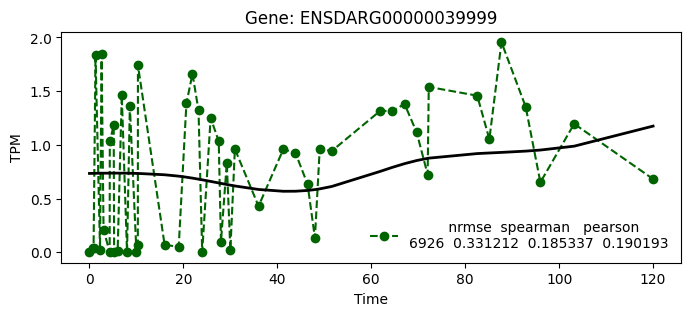

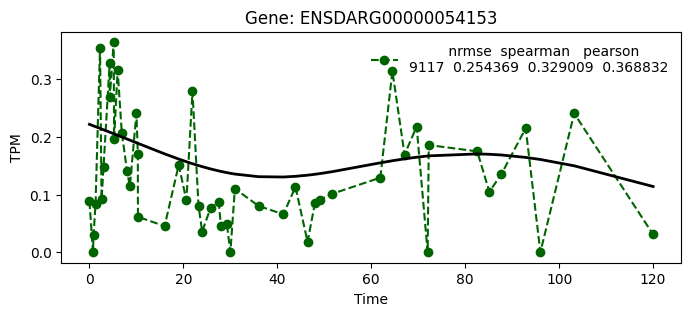

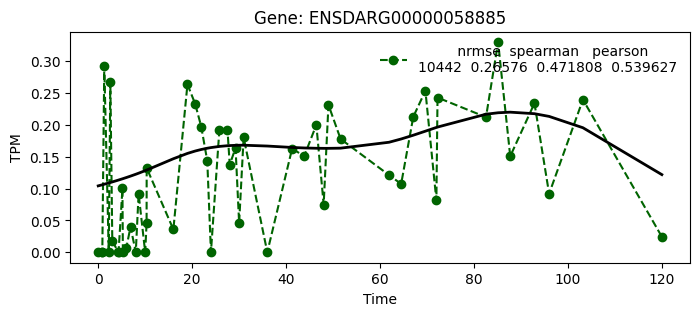

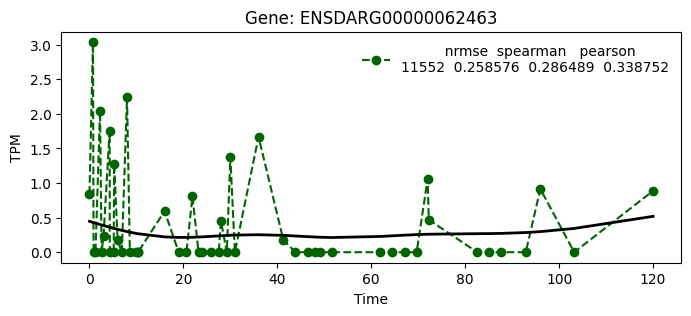

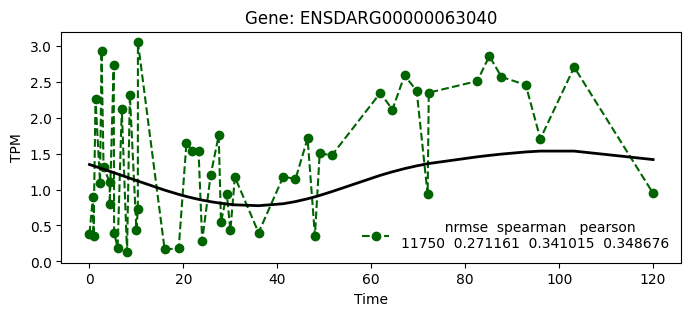

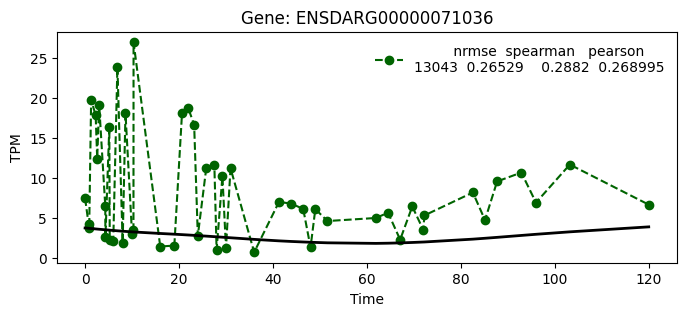

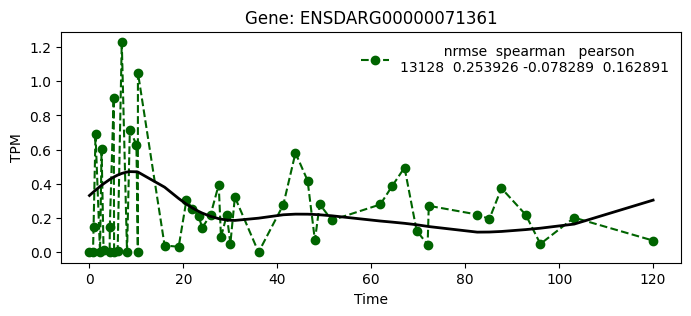

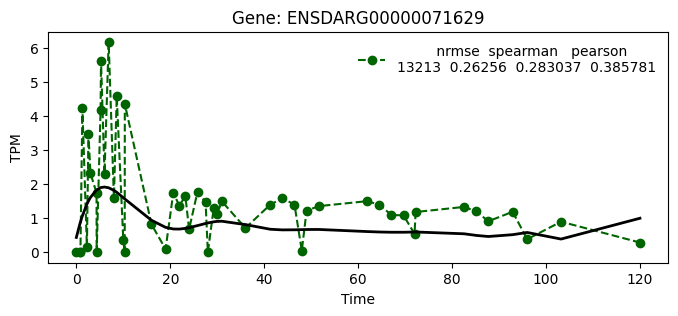

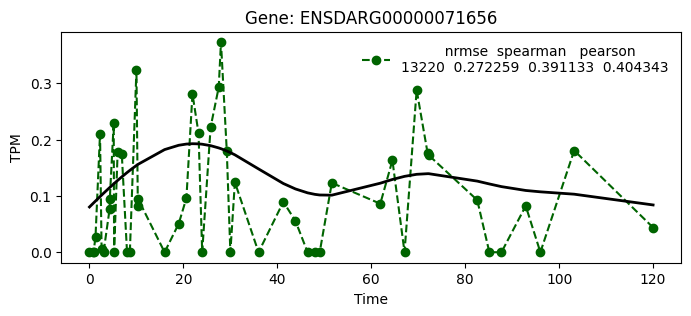

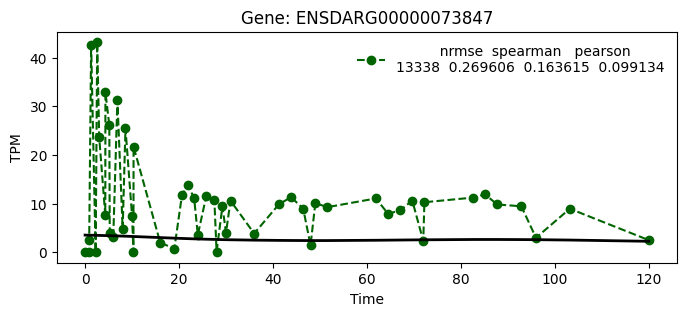

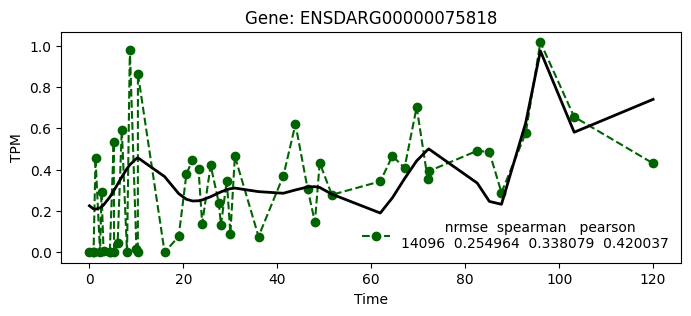

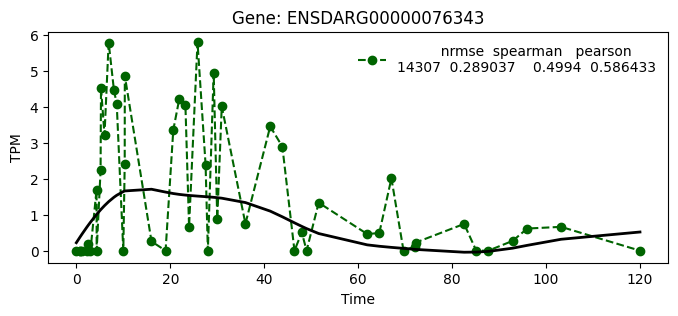

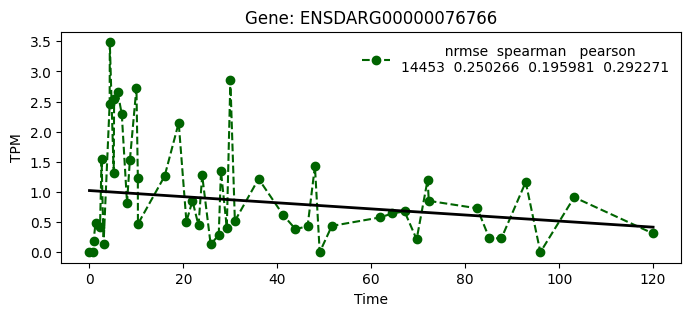

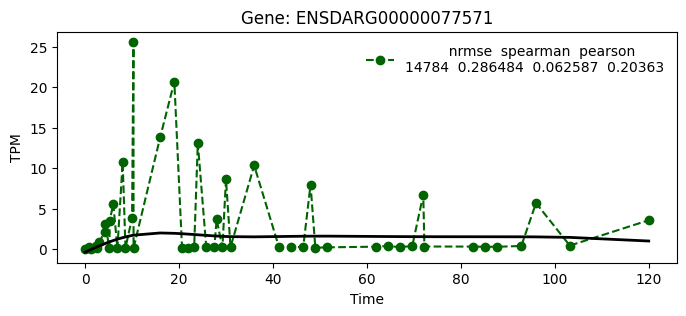

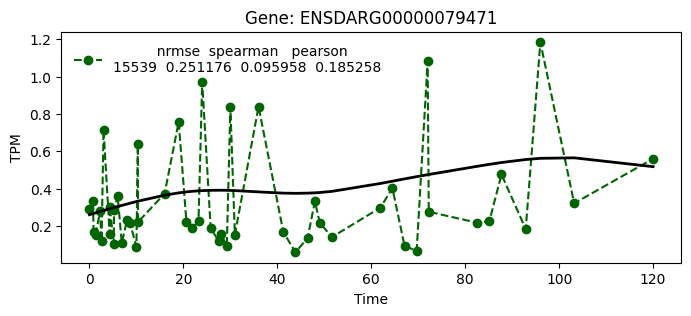

In [54]:
#for g in accepted_genes[0:20]:
for g in rejected_genes[0:20]:
    y_true = ds.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds.time, y_true.mean(dim="source"), marker="o", ls="--", c="darkgreen",
             label=gof120.loc[gof120["ensembl_gene_id"] == g][["nrmse","spearman", "pearson"]])
    plt.plot(y_pred.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("TPM")
    plt.legend(frameon=False)
    plt.show()

### Cluster center GOF

Number of genes in dataset: 28601


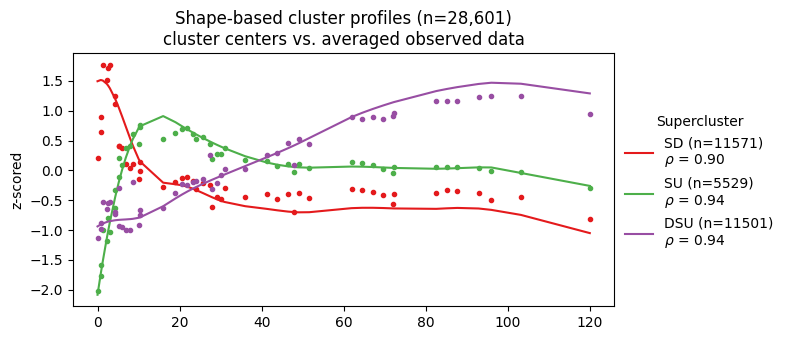

,supercluster,RMSE,r2,spearmanr,pearsonr
0,SD,0.360286,0.804114,0.903385,0.901655
1,SU,0.144288,0.954612,0.937575,0.978344
2,DSU,0.211139,0.936656,0.935750,0.972173


In [42]:
def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    rmse = np.sqrt(np.mean((a[mask] - b[mask])**2)).item()
    return rmse

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

from scipy.stats import spearmanr, pearsonr

fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_superclusters_centers.nc")
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)

ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time"))) / ds.tpm.std(dim=("time")) #z-score

print(f"Number of genes in dataset: {len(labels.ensembl_gene_id)}")

gof = []

plt.figure(figsize=(8,3.5))
for c in range(fuzzy_cntr.shape[0]):

    gene_ids = labels['ensembl_gene_id'][labels['supercluster'] == c].values

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = ds_c.tpm.mean(dim=("ensembl_gene_id"))

    #ds_c_mean = minmax(ds_c_mean)
    #ds_c_std = minmax(ds_c.tpm.std(dim=("ensembl_gene_id",)))
    #ds_c = zscore(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    center = fuzzy_cntr[c, :]

    #center = minmax(center)

    plt.plot(fuzzy_cntr.time, center, c=cluster_color_dict[gams_cluster_names[c]],
             label=f"{gams_cluster_names[c]} (n={ds_c.ensembl_gene_id.size})\n"+r"$\rho$"+f" = {spearmanr(center, ds_c_mean)[0]:.2f}", )
    plt.plot(ds_c_mean.time, ds_c_mean, ".", c=cluster_color_dict[gams_cluster_names[c]])
    #plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":gams_cluster_names[c], "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("clustering/cluster_validation.xlsx")
    
plt.title(f"Shape-based cluster profiles (n={len(labels.ensembl_gene_id):,})\ncluster centers vs. averaged observed data")
plt.ylabel("z-scored")
plt.legend(loc=(1.01, 0.2), frameon=False, title="Supercluster")
plt.tight_layout()
plt.savefig("clustering/figs/cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

In [61]:
labels.supercluster.to_series().value_counts() / len(labels.ensembl_gene_id) *100

supercluster
4    26.502091
1    22.195730
3    20.787176
0    18.028758
2    12.486245
Name: count, dtype: float64

### Subcluster center GOF

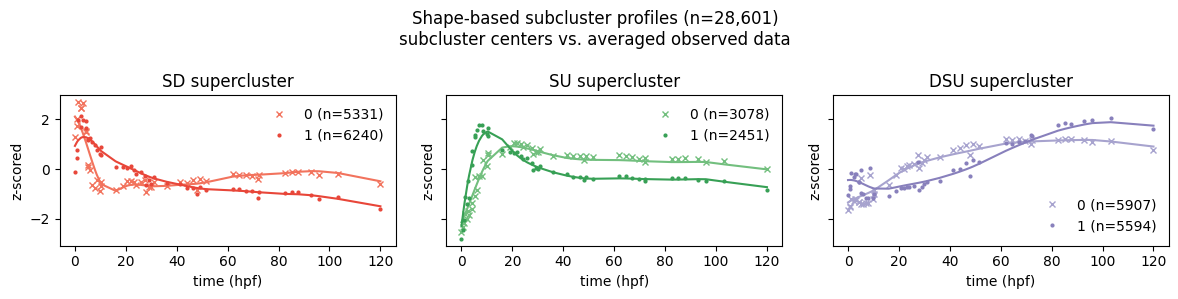

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.390880,0.794545,0.812149,0.922398
1,0,1,0.310000,0.878104,0.975894,0.952960
2,1,0,0.215779,0.937112,0.958896,0.984261
3,1,1,0.312888,0.853788,0.946795,0.960359
4,2,0,0.225330,0.938571,0.957743,0.976616
5,2,1,0.295125,0.884887,0.864106,0.959672


In [22]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)

# mean = ds.tpm.mean(dim=("time",))
# std = ds.tpm.std(dim=("time", ))
# ds["tpm"] = (ds.tpm - mean) / std

gof = []
marker_map = {0:"x", 1:".", 2:"^", 3:"s"}

k_cluster = np.unique(labels.supercluster).size

fig, ax = plt.subplots(1,k_cluster, figsize= (12, 3), sharex=True, sharey=True)
ax=ax.flatten()
for k in range(k_cluster):

    fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_supercluster_{k}_centers.nc")
    for c in range(fuzzy_cntr.shape[0]):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)

        ds_c_mean = zscore(ds_c.tpm.mean(dim=("ensembl_gene_id", )))
        #ds_c_std = minmax(ds_c.tpm.std(dim=("ensembl_gene_id", )))
        center = fuzzy_cntr[c, :]
        #center = minmax(center)

        ax[k].plot(fuzzy_cntr.time, center, c=subcluster_color_map[gams_cluster_names[k]][c])
        ax[k].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=subcluster_color_map[gams_cluster_names[k]][c], 
                   label=f"{c} (n={ds_c.ensembl_gene_id.size})", )
        #ax[k].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
    ax[k].set(title=f"{gams_cluster_names[k]} supercluster", ylabel= "z-scored", xlabel="time (hpf)")
    ax[k].legend(frameon=False)

plt.suptitle(f"Shape-based subcluster profiles (n={len(labels.ensembl_gene_id):,})\nsubcluster centers vs. averaged observed data")
plt.tight_layout()
plt.savefig(f"clustering/figs/subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof).to_excel("clustering/subcluster_validation.xlsx")  
pd.DataFrame(gof)

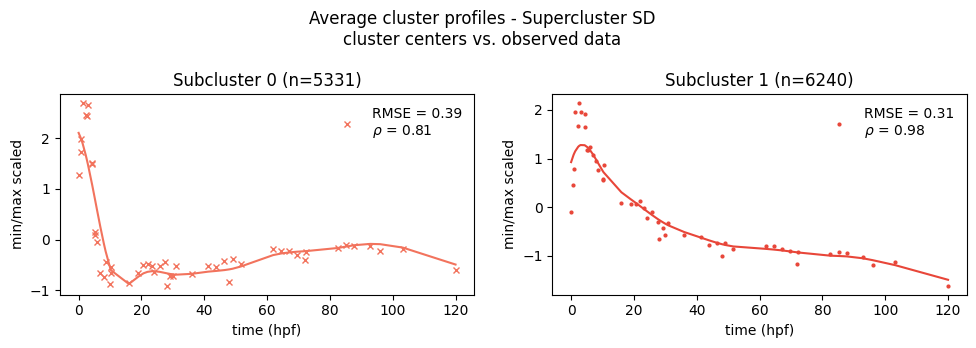

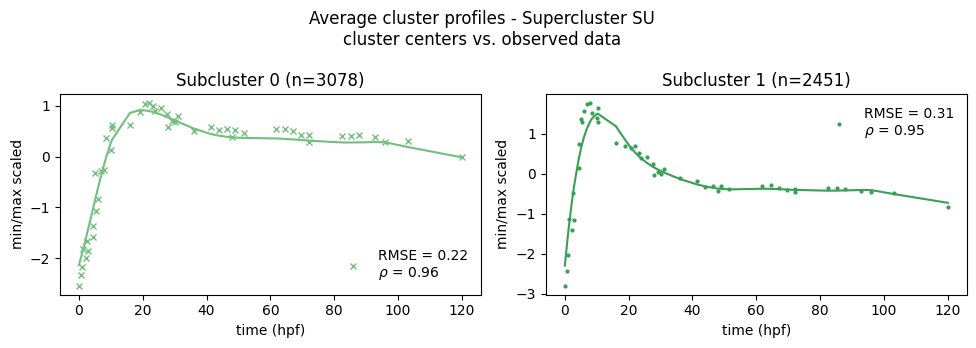

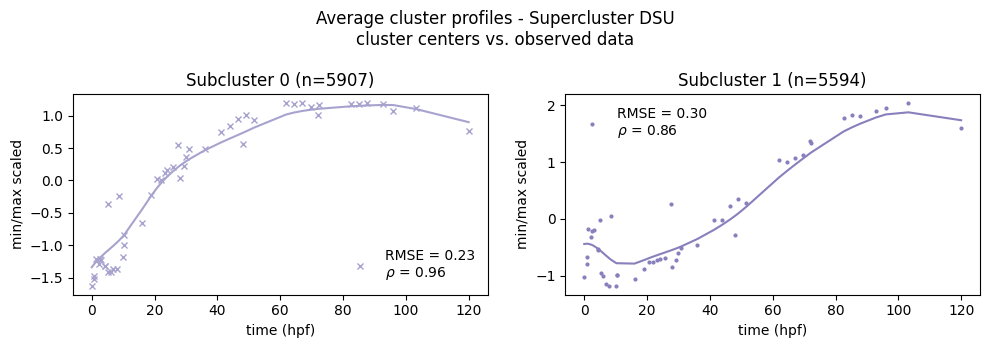

In [ ]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)

gof = []
marker_map = {0:"x", 1:".", 2:"^", 3:"s"}
n_cluster = np.unique(labels.supercluster).size

for k in range(n_cluster):
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_supercluster_{k}_centers.nc")
    sub_cluster = fuzzy_cntr.shape[0]
    fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3.5), squeeze=False)
    ax=ax.flatten()

    for c in range(sub_cluster):
        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = zscore(ds_c.tpm.mean(dim=("ensembl_gene_id", )))

        äds_c_std = minmax(ds_c.tpm.std(dim=("ensembl_gene_id", )))
        center = fuzzy_cntr[c, :]
        äcenter = minmax(center)

        ax[c].plot(fuzzy_cntr.time, center, c=subcluster_color_map[gams_cluster_names[k]][c])
        ax[c].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=subcluster_color_map[gams_cluster_names[k]][c],
                   label=f"RMSE = {rmse(center, ds_c_mean):.2f}\n"+r"$\rho$"+f" = {spearmanr(center, ds_c_mean)[0]:.2f}", )
        #ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
        ax[c].set(title=f"Subcluster {c} (n={ds_c.ensembl_gene_id.size})", ylabel= "min/max scaled", xlabel="time (hpf)")
        ax[c].legend(frameon=False)
        #ax[c].set(xlim=(0, 20))
    plt.suptitle(f"Average cluster profiles - Supercluster {gams_cluster_names[k]}\ncluster centers vs. observed data")
    plt.tight_layout()
    #plt.savefig(f"clustering/figs/subcluster_validation_{k}.png", dpi=300)
    plt.show()


## Cluster Heatmap

In [48]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", 
                  algo="hierarchical", source="all", norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)
    t_not = [5.16, 8.6]
    mask = ~ann.time.isin(t_not)
    ann = ann.sel(time=mask)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 120))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source != "all":
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    #tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "zscore":
        X_z = (tpm - tpm.mean("time")) / tpm.std("time")
        
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minmax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ \n Cluster {supercluster}, n={int(still_valid.sum())} ({algo}, {source})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, n={int(still_valid.sum())})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"clustering/figs/{algo}_cluster_heatmap_{source}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

[debug] genes surviving normalisation: 26956 / 26956


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\38445643.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


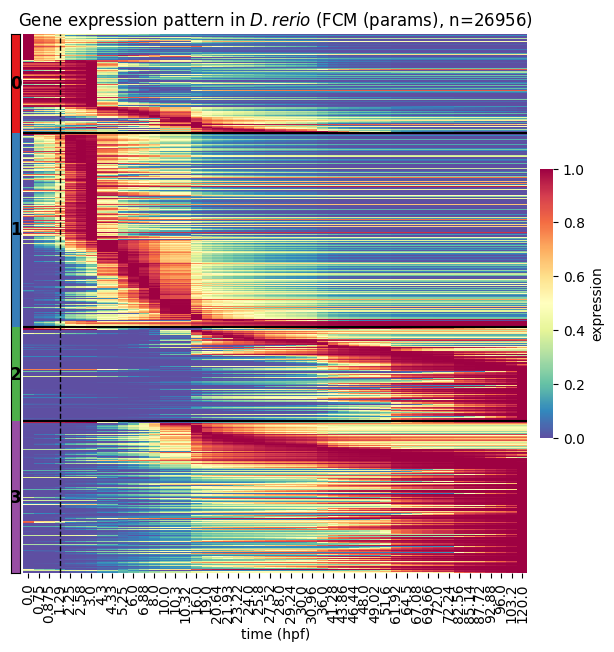

In [51]:
plot_heatmap_supercluster("clustering/joint_simulation_results.nc", cluster_col="supercluster", algo="FCM (params)", norm="minmax",)

[debug] genes surviving normalisation: 28601 / 28601


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\38445643.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


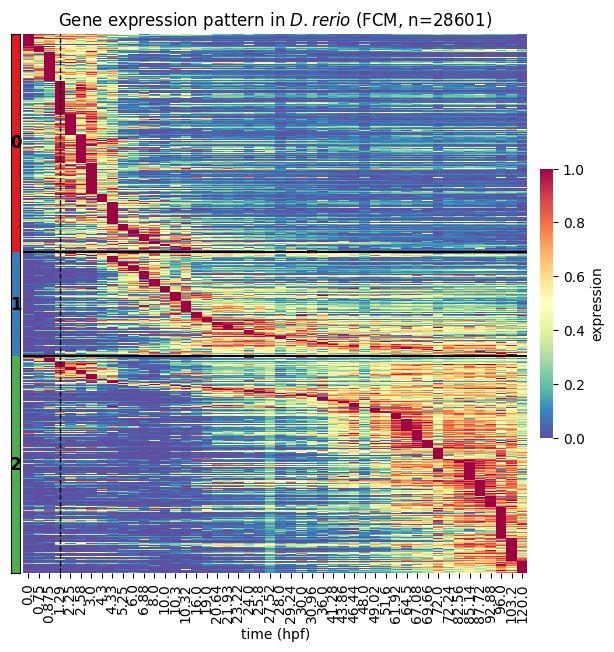

In [50]:
plot_heatmap_supercluster(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc", cluster_col="supercluster", algo="FCM", norm="minmax",)

[debug] genes surviving normalisation: 11571 / 11571


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\38445643.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


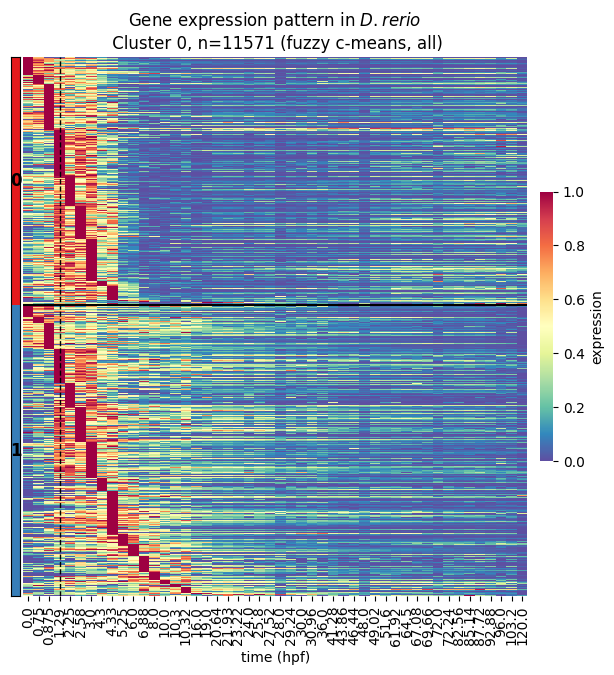

[debug] genes surviving normalisation: 5529 / 5529


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\38445643.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


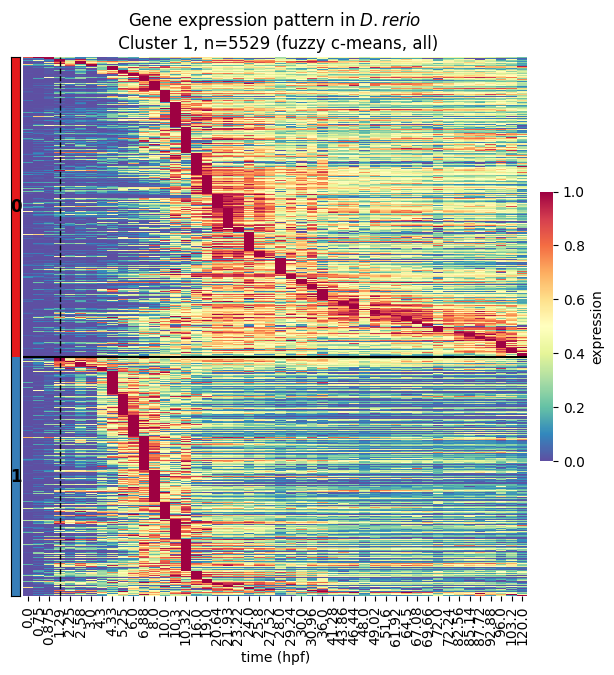

[debug] genes surviving normalisation: 11501 / 11501


C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\38445643.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


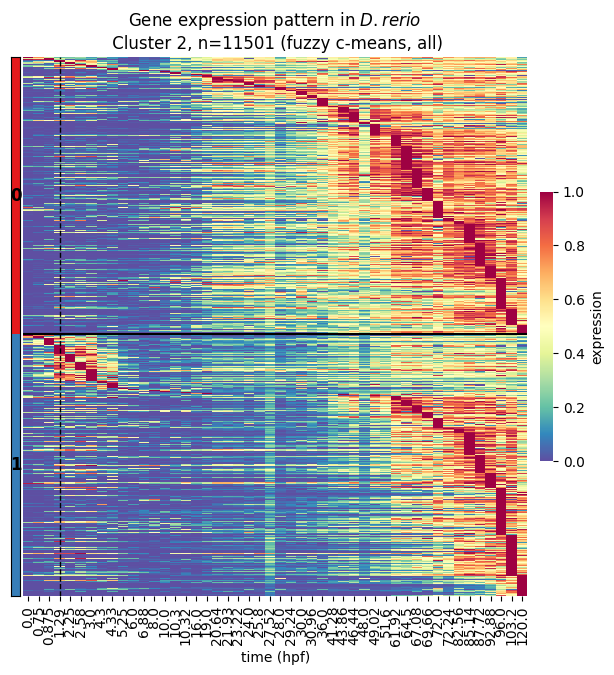

In [26]:
for i in range(n_cluster):
    plot_heatmap_supercluster(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc", cluster_col="subcluster",
                algo="fuzzy c-means", source="all", supercluster=i)

## Model fit Selection by BIC

In [52]:
# load data and combine with supercluster assignment
supercluster = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")
genes = supercluster.ensembl_gene_id.values

gof_all = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")


# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": supercluster["ensembl_gene_id"].values,
    "supercluster_no": supercluster["supercluster"].values,
    "subcluster_no": supercluster["subcluster"].values,
}).set_index("ensembl_gene_id")

lookup["supercluster"]=lookup["supercluster_no"].map(gams_cluster_names)

# Map onto df by gene_id
for df in [gof_all, gof_src, params]:
    df["supercluster"] = df["gene_id"].map(lookup["supercluster"]).fillna("N/A")
    df["supercluster_no"] = df["gene_id"].map(lookup["supercluster_no"]).fillna("N/A")
    df["subcluster_no"] = df["gene_id"].map(lookup["subcluster_no"]).fillna("N/A")

#gof_all = gof_all[gof_all["gene_id"].isin(genes)]
gof_all["model"] = gof_all["model"].map(model_name_map)
print(gof_all.gene_id.nunique())
gof_all

print(np.percentile(gof_all[gof_all["model"]=="Basic"].BIC, (5,95, 50)))
print(np.percentile(gof_all[gof_all["model"]=="M-decay"].BIC, (5,95, 50)))
print(np.percentile(gof_all[gof_all["model"]=="Z-decay"].BIC, (5,95, 50)))

gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")

basic_bic = gof_all[gof_all["model"] == "Basic"].set_index("gene_id")["BIC"]
gof_all["delta_BIC"] = gof_all["BIC"] - gof_all["gene_id"].map(basic_bic)
gof_all[gof_all["delta_BIC"] < -6].value_counts("model") / (gof_all.gene_id.nunique()) *100

gof_all = gof_all[["gene_id", "model","BIC", "delta_BIC", "BIC_rank", "supercluster"]]
gof_all

C:\Users\mgrho\AppData\Local\Temp\ipykernel_7544\1562175610.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")


29308
[-88.69690773 184.05054548  83.41755889]
[-90.98863122 159.88723227  59.51679094]
[-92.11978393 156.71859177  55.37149717]


,gene_id,model,BIC,delta_BIC,BIC_rank,supercluster
0,ENSDARG00000000001,Basic,101.364765,0.000000,3.0,SD
1,ENSDARG00000000002,Basic,79.306205,0.000000,2.0,DSU
2,ENSDARG00000000018,Basic,110.662477,0.000000,3.0,SD
3,ENSDARG00000000019,Basic,20.958594,0.000000,3.0,SD
4,ENSDARG00000000068,Basic,133.565563,0.000000,3.0,SD
...,...,...,...,...,...,...
87916,ENSDARG00000117821,Z-decay,-92.037684,-21.540977,1.0,SD
87917,ENSDARG00000117822,Z-decay,39.808278,20.814297,3.0,SD
87918,ENSDARG00000117823,Z-decay,-10.299152,19.226610,2.0,DSU
87919,ENSDARG00000117824,Z-decay,49.475310,4.049253,2.0,DSU


In [ ]:
# gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
# best_models = gof_all[gof_all["BIC_rank"] == 1]
# best_models.value_counts("model") / (gof_all.gene_id.nunique()) *100

[-88.69690773 184.05054548  83.41755889]
[-90.98863122 159.88723227  59.51679094]
[-92.11978393 156.71859177  55.37149717]


model
Z-decay    62.266275
M-decay    54.398117
Name: count, dtype: float64

In [202]:
## prefered gene-wise
gof_all[gof_all["BIC_rank"] == 1].groupby("model").gene_id.count() / gof_all.gene_id.nunique() * 100

model
Basic      28.118602
M-decay    26.736727
Z-decay    45.144670
Name: gene_id, dtype: float64

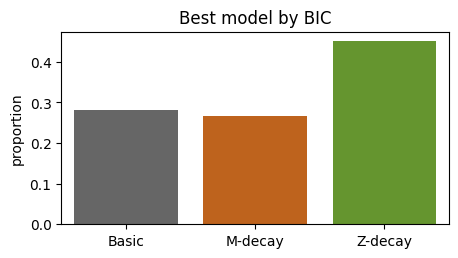

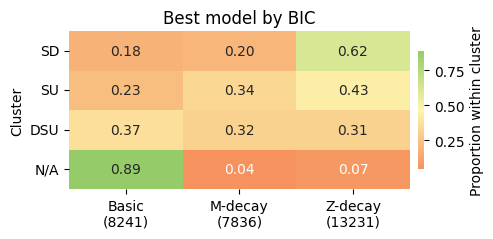

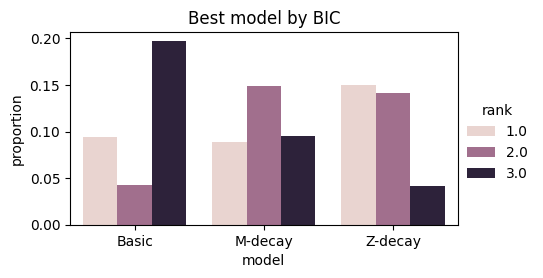

In [53]:
gams_cluster_order = ["SD", "SU", "DSU", "N/A"]
#gams_cluster_order = ["SD", "SU", "DSU", ]

metr = "BIC"
best_models = gof_all.loc[gof_all.groupby("gene_id")[metr].idxmin()]
cluster_counts = pd.crosstab(best_models["model"], best_models["supercluster"])
counts = cluster_counts[gams_cluster_order].T
prop =  cluster_counts[gams_cluster_order] / cluster_counts[gams_cluster_order].sum()
prop = prop.T

labels = [f"{i}\n({counts[i].sum()})" for i in counts.columns]

fig = plt.figure(figsize=(5,2.5))
sns.countplot(best_models, x="model", hue="model",palette=mod_color_dict, order=model_order, stat="proportion")
plt.title(f"Best model by {metr}")
plt.xlabel("")
plt.savefig(f"results/figures/best_by_{metr}.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(5,2.5))
sns.heatmap(prop, annot=True, fmt=".2f", cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': 'Proportion within cluster', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)

ax.set(xlabel="", title=f"Best model by {metr}", ylabel="Cluster")
plt.yticks(rotation=0)
ax.set_xticklabels(labels)
plt.tight_layout()
plt.savefig(f"results/figures/best_by_{metr}_cluster.png", dpi=300)
plt.show()

#best_models = gof_all.loc[gof_all.groupby("gene_id")["BIC"].idxmin()]
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]

fig = plt.figure(figsize=(5,2.5))
sns.countplot(gof_all, x="model", hue="BIC_rank", stat="proportion")
plt.title("Best model by BIC")
plt.legend(loc=(1.01, 0.2), frameon=False, title="rank")
plt.savefig("results/figures/best_by_bic_rank.png", dpi=300)
plt.show()

### Evaluate early stages by BIC

In [54]:
gams_supercluster = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_{norm}.nc")

params_selected = xr.load_dataset("clustering/joint_params_results.nc")
traj_selected = xr.load_dataset("clustering/joint_simulation_results.nc")
gof = pd.read_csv("clustering/all_prefered_decay_mode.csv",).rename(columns={"ensembl_gene_id":"gene_id"})

params_cluster = xr.load_dataset((f"clustering/results/joint_gene_params_cluster_annotation.nc"))

gof = pd.read_csv("clustering/all_prefered_decay_mode.csv",).rename(columns={"ensembl_gene_id":"gene_id"})
gof_sig = ( gof[["gene_id", "decay_mode", "significant", "dBIC"]].copy().assign(model=lambda d: d["decay_mode"].map(model_map)))
gof_sig

,gene_id,decay_mode,significant,dBIC,model
0,ENSDARG00000000001,Z,True,18.472095,Z-decay
1,ENSDARG00000000002,M,False,4.814891,M-decay
2,ENSDARG00000000018,Z,False,1.984802,Z-decay
3,ENSDARG00000000019,Z,True,13.216392,Z-decay
4,ENSDARG00000000068,Z,False,4.687067,Z-decay
...,...,...,...,...,...
29302,ENSDARG00000117821,Z,True,7.257148,Z-decay
29303,ENSDARG00000117822,M,False,0.230496,M-decay
29304,ENSDARG00000117823,Z,False,0.062224,Z-decay
29305,ENSDARG00000117824,Z,True,9.246474,Z-decay


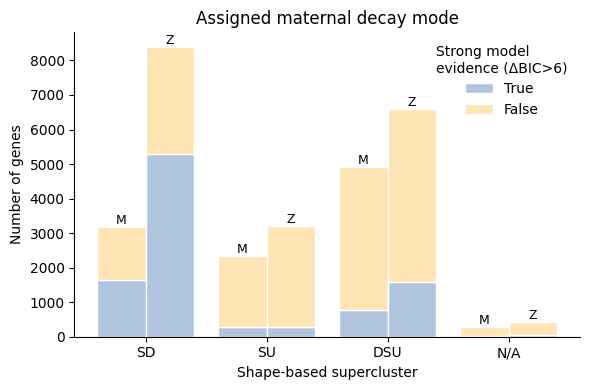

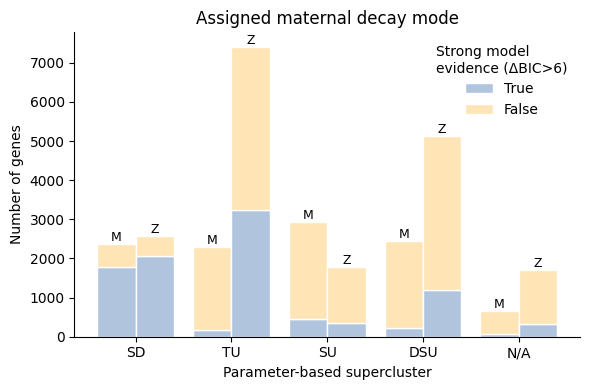

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# paameter-based cluster
supercluster_map = pd.Series( gams_supercluster.supercluster.values,
    index=gams_supercluster.supercluster.coords["ensembl_gene_id"].values)
subcluster_map = pd.Series( gams_supercluster.subcluster.values,
    index=gams_supercluster.subcluster.coords["ensembl_gene_id"].values)

gof_gams = gof_sig.copy()
gof_gams["supercluster_no"] = gof_gams["gene_id"].map(supercluster_map).fillna("N/A")
gof_gams["subcluster_no"] = gof_gams["gene_id"].map(subcluster_map).fillna("N/A")
gof_gams["model"] = gof_gams["model"].map(model_name_map)
gof_gams["supercluster"] = gof_gams["supercluster_no"].map(gams_cluster_names).fillna("N/A")

# counts per supercluster, decay_mode, significant
summ = (gof_gams.groupby(["supercluster", "decay_mode", "significant"]).size().reset_index(name="n_genes"))

superclusters = gams_cluster_order
decay_modes = sorted(summ["decay_mode"].unique())
sig_values = [True, False]  # stack order: bottom -> top

x = np.arange(len(superclusters))
width = 0.8 / len(decay_modes)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {True: "lightsteelblue", False: "moccasin"}
for i, dm in enumerate(decay_modes):
    bottom = np.zeros(len(superclusters))
    offset = (i - (len(decay_modes) - 1) / 2) * width

    for sig in sig_values:
        vals = []
        for supc in superclusters:
            match = summ[ (summ["supercluster"] == supc) & (summ["decay_mode"] == dm) & (summ["significant"] == sig) ]
            vals.append(match["n_genes"].values[0] if len(match) else 0)
        vals = np.array(vals)

        ax.bar( x + offset, vals, width, bottom=bottom, color=colors[sig],
            label=f"{sig}" if i == 0 else None, edgecolor="white",)
        bottom += vals

# place decay_mode label on top of each stacked bar
    for xi, total in zip(x, bottom):
        ax.text(xi + offset, total + max(bottom) * 0.0, dm, ha="center", va="bottom", fontsize=9 )

ax.set_xticks(x)
ax.set_xticklabels(superclusters)
ax.set_xlabel("Shape-based supercluster")
ax.set_ylabel("Number of genes")
ax.set_title("Assigned maternal decay mode")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Strong model\nevidence (ΔBIC>6)", frameon=False)
plt.tight_layout()
plt.savefig("figures/decay_modes_by_cluster.png")
plt.show()


#-----------------

# paameter-based cluster
supercluster_map = pd.Series( params_cluster.supercluster.values,
    index=params_cluster.supercluster.coords["ensembl_gene_id"].values)
subcluster_map = pd.Series( params_cluster.subcluster.values,
    index=params_cluster.subcluster.coords["ensembl_gene_id"].values)

gof_ode = gof_sig.copy()
gof_ode["supercluster_no"] = gof_ode["gene_id"].map(supercluster_map).fillna("N/A")
gof_ode["subcluster_no"] = gof_ode["gene_id"].map(subcluster_map).fillna("N/A")
gof_ode["model"] = gof_ode["model"].map(model_name_map)
gof_ode["supercluster"] = gof_ode["supercluster_no"].map(p_cluster_names).fillna("N/A")

summ = (gof_ode.groupby(["supercluster", "decay_mode", "significant"]).size().reset_index(name="n_genes"))

superclusters = p_cluster_order
decay_modes = sorted(summ["decay_mode"].unique())
sig_values = [True, False]  # stack order: bottom -> top

x = np.arange(len(superclusters))
width = 0.8 / len(decay_modes)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {True: "lightsteelblue", False: "moccasin"}
for i, dm in enumerate(decay_modes):
    bottom = np.zeros(len(superclusters))
    offset = (i - (len(decay_modes) - 1) / 2) * width

    for sig in sig_values:
        vals = []
        for supc in superclusters:
            match = summ[ (summ["supercluster"] == supc) & (summ["decay_mode"] == dm) & (summ["significant"] == sig) ]
            vals.append(match["n_genes"].values[0] if len(match) else 0)
        vals = np.array(vals)

        ax.bar( x + offset, vals, width, bottom=bottom, color=colors[sig],
            label=f"{sig}" if i == 0 else None, edgecolor="white",)
        bottom += vals

# place decay_mode label on top of each stacked bar
    for xi, total in zip(x, bottom):
        ax.text(xi + offset, total + max(bottom) * 0.0, dm, ha="center", va="bottom", fontsize=9 )

ax.set_xticks(x)
ax.set_xticklabels(superclusters)
ax.set_xlabel("Parameter-based supercluster")
ax.set_ylabel("Number of genes")
ax.set_title("Assigned maternal decay mode")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Strong model\nevidence (ΔBIC>6)", frameon=False)
plt.tight_layout()
plt.savefig("figures/decay_modes_by_p_cluster.png")
plt.show()

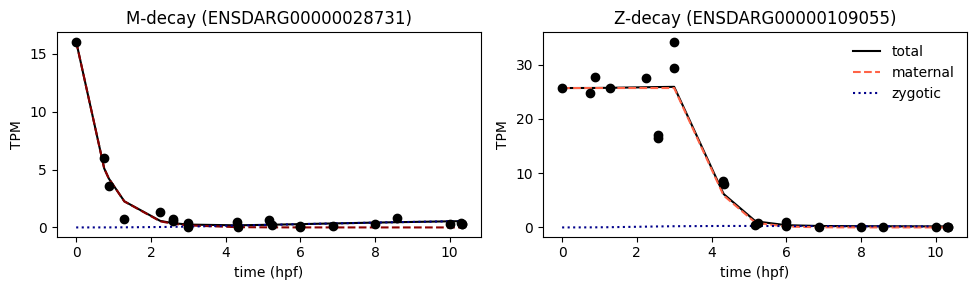

In [56]:
#gof_sig[gof_sig["decay_mode"] == "Z"].sort_values("dBIC")[["gene_id", "dBIC"]]
# best M: ENSDARG00000028731
# best Z: ENSDARG00000109055

import matplotlib.pyplot as plt
import xarray as xr
import arviz as az

data_obs = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0,12))
data_fit = xr.load_dataset("clustering/joint_simulation_results.nc").sel(time=slice(0,12))
m = data_fit.sel(ensembl_gene_id="ENSDARG00000028731")
z = data_fit.sel(ensembl_gene_id="ENSDARG00000109055")

# m0 = az.from_netcdf("case_studies/ENSDARG00000028731/numpyro_posterior.nc").sel(time=slice(0,8))
# hdi_m = az.hdi(m0.posterior_model_fits.mean(dim="source"), 0.95).y
# m = m0.posterior_model_fits.mean(dim=("chain", "draw", "source"))
# z0 = az.from_netcdf("case_studies/ENSDARG00000109055/numpyro_posterior.nc").sel(time=slice(0,8))
# hdi_z = az.hdi(z0.posterior_model_fits.mean(dim="source"), 0.95).y
# z = z0.posterior_model_fits.mean(dim=("chain", "draw", "source"))
#m = az.from_netcdf("../evaluation/8hpf/M-decay/ENSDARG00000069545/numpyro_posterior.nc").posterior_model_fits.mean(dim=("chain", "draw"))
#z = az.from_netcdf("../evaluation/8hpf/Z-decay/ENSDARG00000015657/numpyro_posterior.nc").posterior_model_fits.mean(dim=("chain", "draw"))
# ds_m = m0.observed_data
# ds_z = z0.observed_data

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))
ax1.plot(m.time, m.tpm, "k", label="total",)
ax1.plot(m.time, m.M, "--", label="maternal", c="darkred")
ax1.plot(m.time, m.Z,  ":", label="zygotic", c="darkblue")
#ax1.fill_between(hdi_m.time, *hdi_m.values.T, color="lightgrey", alpha=0.5)
ax1.plot(data_obs.time, data_obs.tpm.sel(ensembl_gene_id="ENSDARG00000028731"), "ko")
ax1.set(title="M-decay (ENSDARG00000028731)", xlabel="time (hpf)", ylabel="TPM")

ax2.plot(z.time, z.tpm, "k",label="total")
ax2.plot(z.time, z.M, "--", label="maternal",  c="tomato")
ax2.plot(z.time, z.Z,  ":", label="zygotic",  c="darkblue")
#ax2.fill_between(hdi_z.time,  *hdi_z.values.T, color="lightgrey", alpha=0.5)
ax2.plot(data_obs.time, data_obs.tpm.sel(ensembl_gene_id="ENSDARG00000109055"), "ko")
ax2.set(title="Z-decay (ENSDARG00000109055)", xlabel="time (hpf)", ylabel="TPM")
ax2.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/decay_modes_fit.png")

0 genes with all-NaN tpm across time
[]
0 genes with all-NaN tpm across time
[]


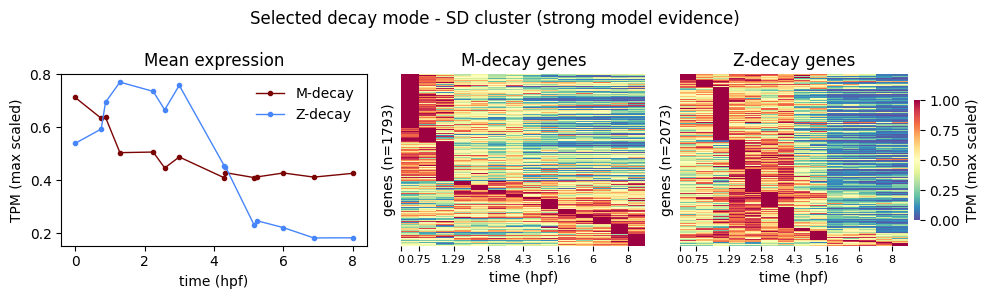

In [60]:
import seaborn as sns
import xarray as xr
from matplotlib import colormaps
import matplotlib.pyplot as plt

## Unterscheidung: pre-ZGA increases / "true" Zygotic decay (stable)

gof_cluster = gof_ode[(gof_ode["supercluster"] == "SD") ].copy()
#gof_cluster = gof_sel[(gof_sel["supercluster"] == "TU-SD")].copy()
#gof_cluster = gof_sel.copy()

colors = colormaps['turbo'].resampled(7)

zgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "Z")].gene_id.values
mgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "M")].gene_id.values

ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0,8)).mean(dim="source")
dm = ds.sel(ensembl_gene_id = mgenes)
dz = ds.sel(ensembl_gene_id = zgenes)

dm = dm / dm.max("time") # max scaled
dz = dz / dz.max("time") # max scaled

all_nan_mask = dm.tpm.isnull().all(dim="time")
bad_genes = dm.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dm = dm.sel(ensembl_gene_id=~all_nan_mask)

all_nan_mask = dz.tpm.isnull().all(dim="time")
bad_genes = dz.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dz = dz.sel(ensembl_gene_id=~all_nan_mask)

# Find time index of max expression for each gene
argmax_time_idx = dm.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dm = dm.isel(ensembl_gene_id=sort_idx)

# Find time index of max expression for each gene
argmax_time_idx = dz.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dz = dz.isel(ensembl_gene_id=sort_idx)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10, 3), width_ratios=(1, 0.8, 0.9))

ax1.plot(dm.time, dm.tpm.mean(dim="ensembl_gene_id"), c=colors(6), lw=1, label="M-decay", marker=".", )
ax1.plot(dz.time, dz.tpm.mean(dim="ensembl_gene_id"), c=colors(1), lw=1, label="Z-decay", marker=".", )
ax1.set(title="Mean expression", xlabel='time (hpf)', ylabel="TPM (max scaled)")
ax1.legend(frameon=False)

hm = sns.heatmap(dm.tpm.T, 
            xticklabels=dm['time'].values,
            yticklabels=dm['ensembl_gene_id'].values,
            ax = ax2,
            cmap='Spectral_r', square=False,
            cbar=False,
            #cbar_kws={'label': 'TPM (max scaled)','shrink': 0.7, 'pad': 0.02 }
            )
ax2.set(title="M-decay genes", xlabel='time (hpf)',  ylabel=f"genes (n={len(dm.ensembl_gene_id)})"     )
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=9)

hm = sns.heatmap(dz.tpm.T, 
            xticklabels=dz['time'].values,
            yticklabels=dz['ensembl_gene_id'].values,
            ax = ax3,
            cmap='Spectral_r', square=False,
            cbar_kws={'label': 'TPM (max scaled)','shrink': 0.7, 'pad': 0.02 })
ax3.set(title="Z-decay genes", xlabel='time (hpf)',  ylabel=f"genes (n={len(dz.ensembl_gene_id)})"     )
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, fontsize=9)

# Keep only a readable subset of time labels on both heatmaps.
xtick_idx = np.linspace(0, len(dm.time) - 1, 8, dtype=int)
xtick_labels = [f"{dm.time.values[i]:g}" for i in xtick_idx]

ax2.set_xticks(xtick_idx)
ax2.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
ax3.set_xticks(xtick_idx)
ax3.set_xticklabels(xtick_labels, rotation=0, fontsize=8)

ax2.set_yticks([])
ax3.set_yticks([])
plt.suptitle(f"Selected decay mode - SD cluster (strong model evidence)")
#plt.suptitle("SD-cluster genes (weak model evidence)")
plt.tight_layout()
plt.savefig(f"figures/strong_model_evidence.png")
#plt.savefig("figures/weak_model_evidence.png")

plt.show()

0 genes with all-NaN tpm across time
[]
0 genes with all-NaN tpm across time
[]


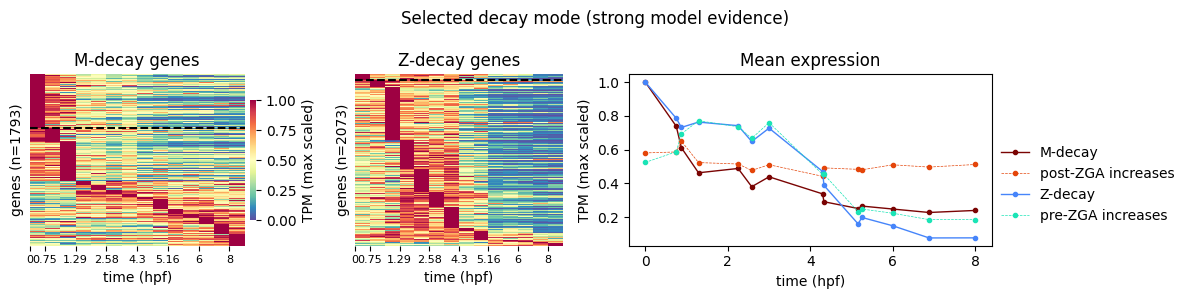

In [61]:
import seaborn as sns
import xarray as xr
from matplotlib import colormaps
import matplotlib.pyplot as plt
import numpy as np

gof_cluster = gof_ode[(gof_ode["supercluster"] == "SD")].copy()
#gof_cluster = gof_ode.copy()

colors = colormaps['turbo'].resampled(7)

zgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "Z")].gene_id.values
mgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "M")].gene_id.values

ds_fit = xr.load_dataset("clustering/joint_simulation_results.nc").sel(time=slice(0, 8))
dm_fit = ds_fit.sel(ensembl_gene_id=mgenes)
dz_fit = ds_fit.sel(ensembl_gene_id=zgenes)

dm_fit = dm_fit / dm_fit.max("time")   # max scaled
dz_fit = dz_fit / dz_fit.max("time")   # max scaled


ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 8)).mean(dim="source")

dm = ds.sel(ensembl_gene_id=mgenes)
dz = ds.sel(ensembl_gene_id=zgenes)

dm = dm / dm.max("time")   # max scaled
dz = dz / dz.max("time")   # max scaled


all_nan_mask = dm.tpm.isnull().all(dim="time")
bad_genes = dm.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dm = dm.sel(ensembl_gene_id=~all_nan_mask)

all_nan_mask = dz.tpm.isnull().all(dim="time")
bad_genes = dz.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dz = dz.sel(ensembl_gene_id=~all_nan_mask)

# Find time index of max expression for each gene
argmax_time_idx = dm.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dm = dm.isel(ensembl_gene_id=sort_idx)

# Find time index of max expression for each gene
argmax_time_idx = dz.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dz = dz.isel(ensembl_gene_id=sort_idx)

# actual t_max values (post-sort, so aligned with dz's current gene order)
t_max = dz.time.values[dz.tpm.argmax(dim="time").values]
t_maxm = dm.time.values[dm.tpm.argmax(dim="time").values]

# split by t_max threshold
T_THRESH = 0.5
# -- M-decay genes
true_m_mask = t_maxm < T_THRESH
post_zga_mask = ~true_m_mask
true_mdecay = dm.isel(ensembl_gene_id=true_m_mask)
post_zga = dm.isel(ensembl_gene_id=post_zga_mask)
# -- Z-decay genes
true_z_mask = t_max < T_THRESH
pre_zga_mask = ~true_z_mask
true_zdecay = dz.isel(ensembl_gene_id=true_z_mask)
pre_zga = dz.isel(ensembl_gene_id=pre_zga_mask)

n_true_z = true_zdecay.sizes["ensembl_gene_id"]   # boundary row index for the heatmap
n_true_m = true_mdecay.sizes["ensembl_gene_id"]   # boundary row index for the heatmap


fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(12, 3), width_ratios=(1.0, 0.8, 1.4))

ax1.plot(true_mdecay.time, true_mdecay.tpm.mean(dim="ensembl_gene_id"), c=colors(6), lw=1, label="M-decay", marker=".")
ax1.plot(post_zga.time, post_zga.tpm.mean(dim="ensembl_gene_id"), c=colors(5), lw=0.5, ls="--", label="post-ZGA increases", marker=".")

ax1.plot(true_zdecay.time, true_zdecay.tpm.mean(dim="ensembl_gene_id"), c=colors(1), lw=1, label="Z-decay", marker=".")
ax1.plot(pre_zga.time, pre_zga.tpm.mean(dim="ensembl_gene_id"), c=colors(2), lw=0.5, ls="--", label="pre-ZGA increases", marker=".")
ax1.set(title="Mean expression", xlabel='time (hpf)', ylabel="TPM (max scaled)")
ax1.legend(loc=(1.01, 0.1),frameon=False)

hm = sns.heatmap(dm.tpm.T,
            xticklabels=dm['time'].values,
            yticklabels=dm['ensembl_gene_id'].values,
            ax=ax2,
            cmap='Spectral_r', square=False,
            cbar_kws={'label': 'TPM (max scaled)', 'shrink': 0.7, 'pad': 0.02})
           
ax2.set(title="M-decay genes", xlabel='time (hpf)', ylabel=f"genes (n={len(dm.ensembl_gene_id)})")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=9)

hm = sns.heatmap(dz.tpm.T,
            xticklabels=dz['time'].values,
            yticklabels=dz['ensembl_gene_id'].values,
            ax=ax3,
            cmap='Spectral_r', square=False, cbar=False)

ax3.set(title="Z-decay genes", xlabel='time (hpf)', ylabel=f"genes (n={len(dz.ensembl_gene_id)})")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, fontsize=9)

# boundary line separating true Z-decay (top) from pre-ZGA (bottom) in the heatmap
ax3.axhline(n_true_z, color='k', linewidth=1.5, ls='--')
ax2.axhline(n_true_m, color='k', linewidth=1.5, ls='--')

# Keep only a readable subset of time labels on both heatmaps.
xtick_idx = np.linspace(0, len(dm.time) - 1, 8, dtype=int)
xtick_labels = [f"{dm.time.values[i]:g}" for i in xtick_idx]

ax2.set_xticks(xtick_idx)
ax2.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
ax3.set_xticks(xtick_idx)
ax3.set_xticklabels(xtick_labels, rotation=0, fontsize=8)

ax2.set_yticks([])
ax3.set_yticks([])
plt.suptitle(f"Selected decay mode (strong model evidence)")
#fig.subplots_adjust(left=0.05, right=0.95, wspace=0.1)
plt.tight_layout()
plt.savefig(f"figures/strong_model_evidence1.png")
plt.show()

In [65]:
ds_fit

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 26956, time: 14)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000016479' ... 'ENSDA...
    model            (ensembl_gene_id) object 'M' 'Z' 'M' 'M' ... 'Z' 'Z' 'Z'
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 5.25 6.0 6.88 8.0
Data variables:
    M                (ensembl_gene_id, time) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Z                (ensembl_gene_id, time) float64 0.0 0.0001758 ... 8.569e-66
    tpm              (ensembl_gene_id, time) float64 0.0 0.0001758 ... 8.569e-66
    repression       (ensembl_gene_id, time) float64 nan nan nan ... 1.0 1.0 1.0
    supercluster     (ensembl_gene_id) int32 2 3 2 2 2 2 3 1 ... 2 1 1 0 1 1 3 2

0 genes with all-NaN tpm across time
[]
0 genes with all-NaN tpm across time
[]


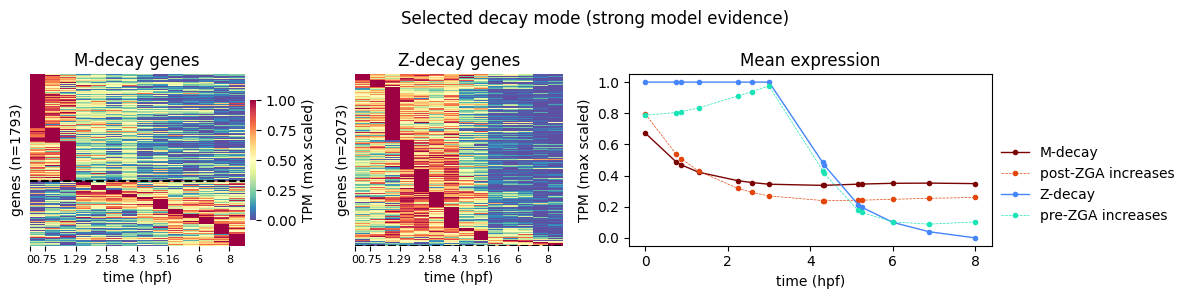

In [ ]:
import seaborn as sns
import xarray as xr
from matplotlib import colormaps
import matplotlib.pyplot as plt
import numpy as np

gof_cluster = gof_ode[(gof_ode["supercluster"] == "SD")].copy()
#gof_cluster = gof_sel.copy()

colors = colormaps['turbo'].resampled(7)

zgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "Z")].gene_id.values
mgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "M")].gene_id.values

ds_fit = xr.load_dataset("clustering/joint_simulation_results.nc").sel(time=slice(0, 8)).tpm
ds_fit = (ds_fit - ds_fit.min("time")) / (ds_fit.max("time")- ds_fit.min("time"))   # max scaled

dm_fit = ds_fit.sel(ensembl_gene_id=mgenes)
dz_fit = ds_fit.sel(ensembl_gene_id=zgenes)

ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 8)).mean(dim="source").tpm
ds = (ds - ds.min("time")) / (ds.max("time")- ds.min("time"))   # max scaled

dm = ds.sel(ensembl_gene_id=mgenes)
dz = ds.sel(ensembl_gene_id=zgenes)

all_nan_mask = dm.isnull().all(dim="time")
bad_genes = dm.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dm = dm.sel(ensembl_gene_id=~all_nan_mask)
dm_fit = dm_fit.sel(ensembl_gene_id=~all_nan_mask)

all_nan_mask = dz.isnull().all(dim="time")
bad_genes = dz.ensembl_gene_id.values[all_nan_mask.values]
print(f"{len(bad_genes)} genes with all-NaN tpm across time")
print(bad_genes[:10])
dz = dz.sel(ensembl_gene_id=~all_nan_mask)
dz_fit = dz_fit.sel(ensembl_gene_id=~all_nan_mask)

# Find time index of max expression for each gene
argmax_time_idx = dm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dm = dm.isel(ensembl_gene_id=sort_idx)

# Find time index of max expression for each gene
argmax_time_idx = dz.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dz = dz.isel(ensembl_gene_id=sort_idx)

# actual t_max values (post-sort, so aligned with dz's current gene order)
t_max = dz.time.values[dz.argmax(dim="time").values]
t_maxm = dm.time.values[dm.argmax(dim="time").values]

# split by t_max threshold
T_THRESH = 1.0
# -- M-decay genes
true_m_mask = t_maxm < T_THRESH
post_zga_mask = ~true_m_mask

#true_mdecay = dm_fit.isel(ensembl_gene_id=true_m_mask)
#post_zga = dm_fit.isel(ensembl_gene_id=post_zga_mask)

true_zdecay = dm_fit.where(dm_fit.sel(time=0)==1)
pre_zga = dm_fit.where(dm_fit.sel(time=3)< dz_fit.sel(time=8))

# -- Z-decay genes
true_z_mask = t_max == 0.0
pre_zga_mask = ~true_z_mask
#true_zdecay = dz_fit.isel(ensembl_gene_id=true_z_mask)
true_zdecay = dz_fit.where(dz_fit.sel(time=0)==1)
pre_zga = dz_fit.where(dz_fit.sel(time=0) < dz_fit.sel(time=3))
#pre_zga = dz_fit.isel(ensembl_gene_id=pre_zga_mask)

n_true_z = true_zdecay.sizes["ensembl_gene_id"]   # boundary row index for the heatmap
n_true_m = true_mdecay.sizes["ensembl_gene_id"]   # boundary row index for the heatmap

fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(12, 3), width_ratios=(1.0, 0.8, 1.4))

ax1.plot(true_mdecay.time, true_mdecay.mean(dim="ensembl_gene_id"), c=colors(6), lw=1, label="M-decay", marker=".")
ax1.plot(post_zga.time, post_zga.mean(dim="ensembl_gene_id"), c=colors(5), lw=0.5, ls="--", label="post-ZGA increases", marker=".")

ax1.plot(true_zdecay.time, true_zdecay.mean(dim="ensembl_gene_id"), c=colors(1), lw=1, label="Z-decay", marker=".")
ax1.plot(pre_zga.time, pre_zga.mean(dim="ensembl_gene_id"), c=colors(2), lw=0.5, ls="--", label="pre-ZGA increases", marker=".")
ax1.set(title="Mean expression", xlabel='time (hpf)', ylabel="TPM (max scaled)")
ax1.legend(loc=(1.01, 0.1),frameon=False)

hm = sns.heatmap(dm.T,
            xticklabels=dm['time'].values,
            yticklabels=dm['ensembl_gene_id'].values,
            ax=ax2,
            cmap='Spectral_r', square=False,
            cbar_kws={'label': 'TPM (max scaled)', 'shrink': 0.7, 'pad': 0.02})
           
ax2.set(title="M-decay genes", xlabel='time (hpf)', ylabel=f"genes (n={len(dm.ensembl_gene_id)})")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=9)

hm = sns.heatmap(dz.T,
            xticklabels=dz['time'].values,
            yticklabels=dz['ensembl_gene_id'].values,
            ax=ax3,
            cmap='Spectral_r', square=False, cbar=False)

ax3.set(title="Z-decay genes", xlabel='time (hpf)', ylabel=f"genes (n={len(dz.ensembl_gene_id)})")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, fontsize=9)

# boundary line separating true Z-decay (top) from pre-ZGA (bottom) in the heatmap
ax3.axhline(n_true_z, color='k', linewidth=1.5, ls='--')
ax2.axhline(n_true_m, color='k', linewidth=1.5, ls='--')

# Keep only a readable subset of time labels on both heatmaps.
xtick_idx = np.linspace(0, len(dm.time) - 1, 8, dtype=int)
xtick_labels = [f"{dm.time.values[i]:g}" for i in xtick_idx]

ax2.set_xticks(xtick_idx)
ax2.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
ax3.set_xticks(xtick_idx)
ax3.set_xticklabels(xtick_labels, rotation=0, fontsize=8)

ax2.set_yticks([])
ax3.set_yticks([])
plt.suptitle(f"Selected decay mode (strong model evidence)")
#fig.subplots_adjust(left=0.05, right=0.95, wspace=0.1)
plt.tight_layout()
plt.savefig(f"figures/strong_model_evidence2.png")
plt.show()

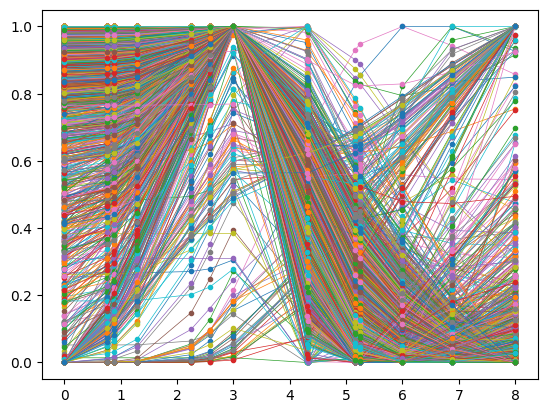

In [81]:
for g in pre_zga.ensembl_gene_id.values:
    plt.plot(pre_zga.time, pre_zga.sel(ensembl_gene_id=g), lw=0.5, marker=".")

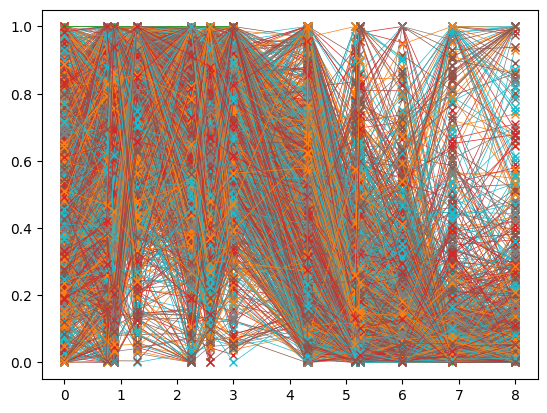

In [82]:
for g in true_zdecay.ensembl_gene_id.values:
    plt.plot(true_zdecay.time, true_zdecay.sel(ensembl_gene_id=g), lw=0.5, marker=".")
    plt.plot(ds.time, ds.sel(ensembl_gene_id=g), lw=0.5, marker="x")

### Heatmap accepted - ODE

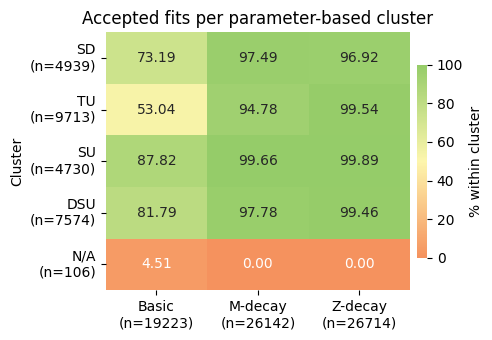

In [85]:
# accepted fit heatmap
subcluster_gene_map = pd.Series(gof_ode.subcluster_no.values, index=gof_ode.gene_id.values)
cluster_gene_map = pd.Series(gof_ode.supercluster.values, index=gof_ode.gene_id.values)

res_plot = res_joined[["gene_id", "model", "status", "NRMSE", "spearman_rho"]].copy()
res_plot["supercluster"] = res_plot["gene_id"].map(cluster_gene_map)
res_plot["subcluster"] = res_plot["gene_id"].map(subcluster_gene_map)
#res_plot["model"] = res_plot["model"].map(model_name_map)

#accepted = res_plot[res_plot["status"] == "fully_accepted"]
accepted = res_plot[res_plot["status"].isin(["fully_accepted", "pattern", "low_error"])]
#accepted["supercluster"] = accepted["supercluster_no"].map(cluster_map)

model_order_p = ["Basic", "M-decay", "Z-decay"]

count_model = accepted["model"].value_counts()
count_cluster = accepted.groupby("supercluster")["gene_id"].nunique()

merged_counts = res_plot.groupby(["model", "supercluster"]).size().reset_index(name="merged")
accepted_counts = accepted.groupby(["model", "supercluster"]).size().reset_index(name="accepted")
result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "supercluster"])

result["accepted"] = result["accepted"].fillna(0).astype(int)
result["ratio"] = result["accepted"] / result["merged"] * 100

# Pivot for heatmap
pivot = result.pivot(index="supercluster", columns="model", values="ratio") 
pivot = pivot.reindex(index=p_cluster_order, columns=model_order_p)

fig, ax = plt.subplots(figsize=(5,3.5))
sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
            cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': '% within cluster', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)


ax.set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
ax.set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

ax.set(xlabel="", title=f"Accepted fits per parameter-based cluster", ylabel="Cluster")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"results/figures/accepted_params_heatmap_gof.png", dpi=300)
plt.show()

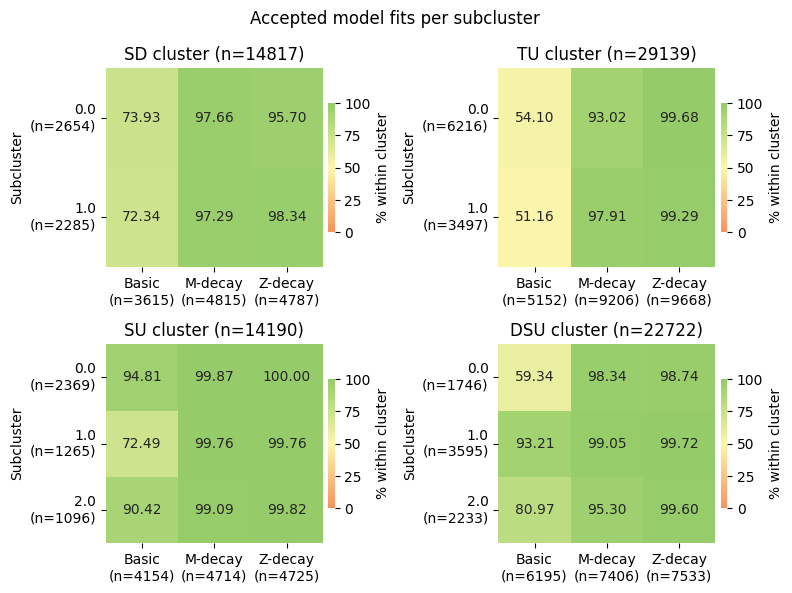

In [84]:
# accepted fit heatmap per subcluster
res_plot = res_joined.reset_index()[["gene_id", "model", "status"]]
res_plot["supercluster"] = res_plot["gene_id"].map(cluster_gene_map)
res_plot["subcluster"] = res_plot["gene_id"].map(subcluster_gene_map)

fig, ax = plt.subplots(2,2, figsize=(8,6), sharey=False)
ax=ax.flatten()
for x, i in enumerate(p_cluster_order[:4]):

    d = res_plot[res_plot["supercluster"] == i]
    #accepted = d[d["status"] == "fully_accepted"]
    accepted = d[d["status"].isin(["fully_accepted", "pattern", "low_error"])]

    count_model = accepted["model"].value_counts()
    count_cluster = accepted.groupby("subcluster")["gene_id"].nunique()

    merged_counts = d.groupby(["model", "subcluster"]).size().reset_index(name="merged")
    accepted_counts = accepted.groupby(["model", "subcluster"]).size().reset_index(name="accepted")
    result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "subcluster"])

    result["accepted"] = result["accepted"].fillna(0).astype(int)
    result["ratio"] = result["accepted"] / result["merged"] * 100

    # Pivot for heatmap
    pivot = result.pivot(index="subcluster", columns="model", values="ratio") 
    pivot = pivot.reindex(columns=model_order)

    sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
                cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
                cbar_kws={'label': '% within cluster', 'shrink': 0.65, 'pad': 0.02 }, alpha=0.8, ax=ax[x] )

    ax[x].set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
    ax[x].set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

    ax[x].set(xlabel="", title=f"{i} cluster (n={len(d)})", ylabel="Subcluster")
    plt.yticks(rotation=0)

plt.suptitle("Accepted model fits per subcluster")
plt.tight_layout()
plt.savefig(f"results/figures/accepted_heatmap_gof_subcluster_param.png", dpi=300)
plt.show()

## load reduced dataset


In [235]:
params_selected = xr.load_dataset("clustering/joint_params_results.nc")
traj_selected = xr.load_dataset("clustering/joint_simulation_results.nc")
gof = pd.read_csv("clustering/prefered_decay_mode.csv",).rename(columns={"ensembl_gene_id":"gene_id"})
ds_params = pd.read_csv("results/results_summary/params_combined.csv")

model_map = {"Z": "Rep_Z", "M": "Rep_M"}
gof_sel = ( gof[["gene_id", "decay_mode"]].copy().assign(model=lambda d: d["decay_mode"].map(model_map)))
ds_params_selected = ( ds_params.merge(gof_sel, how="inner", on=["gene_id", "model"] ))
ds_params_selected.decay_mode.value_counts()

decay_mode
Z    16897
M    10057
Name: count, dtype: int64

## Parameter-cluster scatterplot

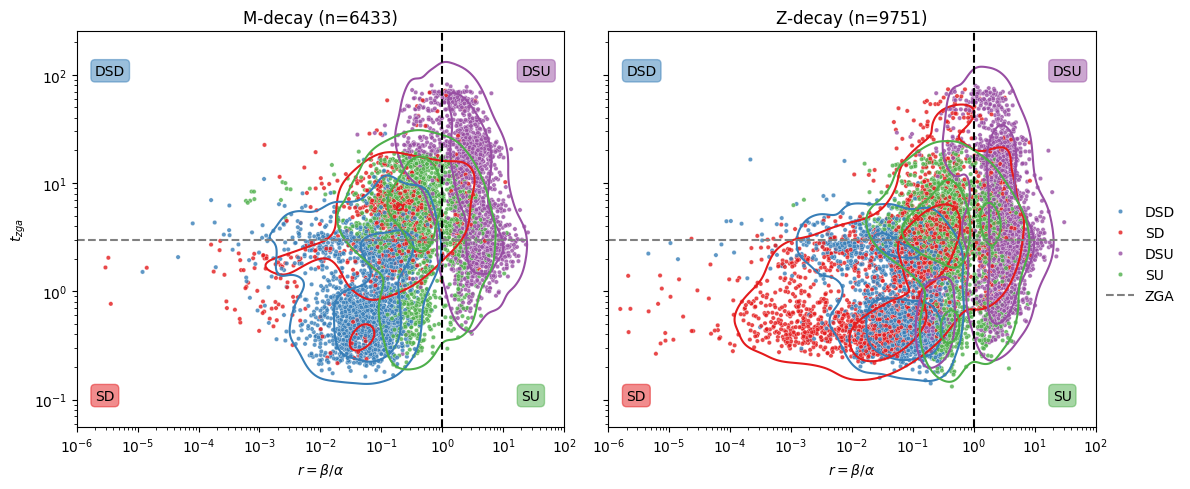

In [ ]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

#params = pd.read_csv("results/results_summary/params_combined.csv")
params =  ds_params_selected.copy()
params = params[params["gene_id"].isin(genes_acc)]

df = params[params["model"] != "Basic"].copy()
df["beta_mean"] = df["beta_mean"].clip(lower=1e-5)
df["alpha_mean"] = df["alpha_mean"].clip(lower=1e-5)
df["t_zga_mean"] = df["t_zga_mean"].clip(upper=120)


df["r"] = df["beta_mean"] / df["alpha_mean"]
#df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(df_m, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", s=10, palette=cluster_color_dict, alpha=0.8, legend=False)
sns.scatterplot(df_z, x="r", y="t_zga_mean", ax=ax2, hue="supercluster", s=10, palette=cluster_color_dict, alpha=0.8, legend=True)

sns.kdeplot(df_m, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=3)
sns.kdeplot(df_z, x="r",  y="t_zga_mean", hue="supercluster", ax=ax2, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=3)

ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title=f"M-decay (n={len(df_m)})", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax2.set(xlabel="$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title=f"Z-decay (n={len(df_z)})", xscale="log", yscale="log", xlim=(1e-6, 1e2), )

ax1.axvline(1, c="k", ls="--")
ax2.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")
ax2.axhline(3, c="gray", ls="--", label="ZGA")
#ax1.axhline(1, c="gray", ls="-.", label="ZGA")
#ax2.axhline(1, c="gray", ls="-.", label="ZGA")

ax1.text(x=2e-6, y=100, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=0.1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=100, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=0.1,s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax2.text(x=2e-6, y=100, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e-6, y=0.1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=100, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=0.1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

#ax1.legend(loc=(0.1,0.7),frameon=False)
ax2.legend(loc=(1.01,0.3),frameon=False)
plt.tight_layout()
plt.savefig("results/figures/scatter_params_cluster_tzga.png", dpi=300)
plt.show()

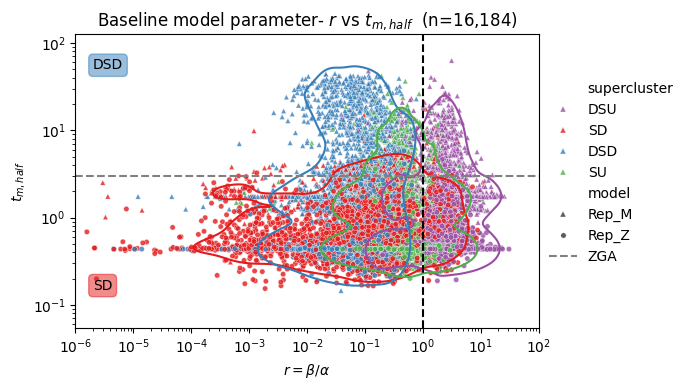

In [118]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

params =  ds_params_selected.copy()
params = params[params["gene_id"].isin(genes_acc)]


df = params[params["model"] != "Basic"].copy()
df["beta_mean"] = df["beta_mean"].clip(lower=1e-5)
df["alpha_mean"] = df["alpha_mean"].clip(lower=1e-5)
df["t_zga_mean"] = df["t_zga_mean"].clip(upper=120)

df["r"] = df["beta_mean"] / df["alpha_mean"]

df["maternal_half_life"] = np.log(2) / df["delta_m_mean"] ## maternal half-life --> downregulation cluster

fig, (ax1) = plt.subplots(1,1, figsize=(7,4), sharex=True, sharey=True)
sns.scatterplot(df, x="r", y="maternal_half_life", ax=ax1,  hue="supercluster", style="model", markers={"Rep_M":"^", "Rep_Z":"o"}, s=15, palette=cluster_color_dict, alpha=0.8, legend=True)
sns.kdeplot(df, x="r", y="maternal_half_life",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=1)
ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{m, half}$", 
        title=f"Baseline model parameter"+"- $r$ vs $t_{m, half}$ "+f" (n={len(df):,})", 
        xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax1.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")

ax1.text(x=2e-6, y=50, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=0.15, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
#ax1.text(x=2e1, y=50, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
#ax1.text(x=2e1, y=0.15,s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax1.legend(loc=(1.01,0.2),frameon=False)
plt.tight_layout()
plt.savefig("results/figures/scatter_params_cluster_tm12_joint.png", dpi=300)
plt.show()

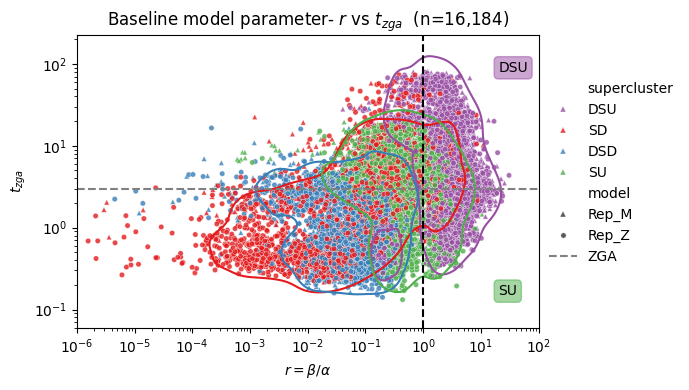

In [ ]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

params =  ds_params_selected.copy()
params = params[params["gene_id"].isin(genes_acc)]

df = params[params["model"] != "Basic"].copy()
df["beta_mean"] = df["beta_mean"].clip(lower=1e-5)
df["alpha_mean"] = df["alpha_mean"].clip(lower=1e-5)
df["t_zga_mean"] = df["t_zga_mean"].clip(upper=120)     # --> upregulation

df["r"] = df["beta_mean"] / df["alpha_mean"] 

fig, (ax1) = plt.subplots(1,1, figsize=(7,4), sharex=True, sharey=True)
sns.scatterplot(df, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", style="model", markers={"Rep_M":"^", "Rep_Z":"o"}, s=15, palette=cluster_color_dict, alpha=0.8, legend=True)
sns.kdeplot(df, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=1)
ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", 
        title=f"Baseline model parameter"+"- $r$ vs $t_{zga}$ "+f" (n={len(df):,})",
          xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax1.axvline(1, c="k", ls="--")
ax1.axhline(5, c="gray", ls="--", label="ZGA")

#ax1.text(x=2e-6, y=80, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
#ax1.text(x=2e-6, y=0.15, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=80, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=0.15,s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax1.legend(loc=(1.01,0.2),frameon=False)
plt.tight_layout()
plt.savefig("results/figures/scatter_params_cluster_tzga_joint.png", dpi=300)
plt.show()

  supercluster     agree
0          DSD  0.025346
1          DSU  0.471888
2           SD  0.758157
3           SU  0.178434


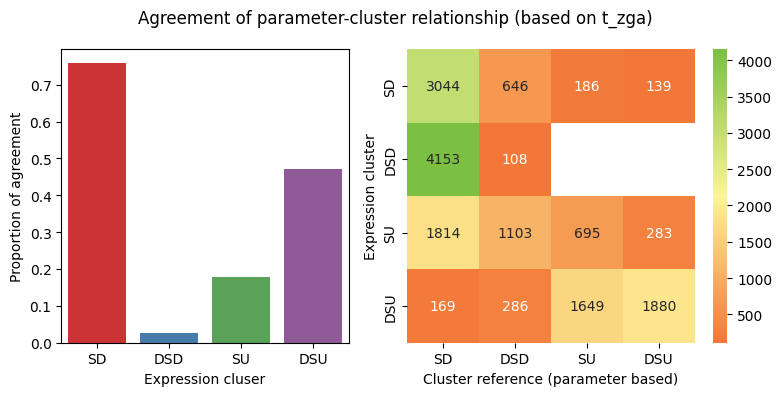

'\nparam_cluster1 = param_cluster[param_cluster["model"] == "Rep_Z"]\nres_df = param_cluster1.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()\n\ndf_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")\nimport seaborn as sns\ncmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)\n\nfig, ax = plt.subplots(1,2, figsize=(12, 4), sharey= True)\nsns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[0])\nax[0].set(title="Z-decay",ylabel="Supercluster",xlabel="Supercluster reference")\n# Z-decay\nparam_cluster2 = param_cluster[param_cluster["model"] == "Rep_M"]\nres_df = param_cluster2.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()\n\ndf_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")\ncmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)\nsns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[1])\nax[1].set(title="M-decay",ylabel="",xlabe

In [ ]:
# ds_params = pd.read_csv("results/results_summary/params_combined.csv")
# df = ds_params[ds_params["model"] != "Basic" ].copy()


df = ds_params_selected.copy()
df = df[df["gene_id"].isin(genes_acc)]


df["r"] = df["beta_mean"] / df["alpha_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]
df = df[df["r"] > 1e-5]

param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_reg_mean", "t_half_m", "supercluster"]].copy()

import numpy as np

zga_time = 5.0
half_life = 1.0

param_cluster["t_zga"] = param_cluster["t_zga_mean"]
param_cluster["t_reg"] = param_cluster["t_reg_mean"]

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
#param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] <= 1, "dir"] = "down"

param_cluster.loc[param_cluster["t_zga"] <= zga_time, "activation"] = "early"
param_cluster.loc[param_cluster["t_zga"] > zga_time, "activation"] = "late"

param_cluster.loc[param_cluster["t_half_m"] > half_life, "degradation"] = "late"
param_cluster.loc[param_cluster["t_half_m"] <= half_life, "degradation"] = "early"

param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["activation"] == "early"), "cluster_ref"] = "SU"
param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["activation"] == "late"), "cluster_ref"] = "DSU"

param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["activation"] == "early"), "cluster_ref"] = "SD"
param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["activation"] == "late"), "cluster_ref"] = "DSD"

param_cluster["agree"] = False
param_cluster.loc[param_cluster["supercluster"] ==  param_cluster["cluster_ref"], "agree"] = True

#param_cluster.loc[param_cluster["t_reg_mean"] < 2, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_reg_mean"] <= 4) & (param_cluster["t_zga_mean"] >= 2) , "activation"] = "zga"
#param_cluster.loc[param_cluster["t_reg_mean"] > 4, "activation"] = "late"

import seaborn as sns
import matplotlib.pyplot as plt

#res = param_cluster.groupby(["model", "supercluster"])["agree"].mean()
res = param_cluster.groupby(["supercluster"])["agree"].mean()

res_df = res.reset_index()
# columns: model, supercluster, agree

fig, ax = plt.subplots(1,2, figsize=(8, 4), width_ratios=[0.8,1])
#sns.barplot(data=res_df, x="supercluster", y="agree", hue="model", palette=mod_color_dict)
sns.barplot(data=res_df, x="supercluster", y="agree", errorbar=None, hue="supercluster", 
            palette=cluster_color_dict, order=gams_cluster_order, ax=ax[0])

ax[0].set(ylabel="Proportion of agreement", xlabel="Expression cluser")
#plt.legend(title="Model", frameon=False)
#plt.tight_layout()
#plt.savefig("results/figures/simple_parameter_cluster_relationship.png", dpi=300)

print(res_df)
res_df = param_cluster.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()
df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
df_plot = df_plot.reindex(index=gams_cluster_order, columns=gams_cluster_order)
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[1])
ax[1].set(ylabel="Expression cluster",xlabel="Cluster reference (parameter based)")

plt.suptitle("Agreement of parameter-cluster relationship (based on t_zga)")
plt.tight_layout()
plt.savefig("results/figures/simple_parameter_cluster_relationship_all_tzga.png", dpi=300)
plt.show()

'''
param_cluster1 = param_cluster[param_cluster["model"] == "Rep_Z"]
res_df = param_cluster1.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()

df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
import seaborn as sns
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)

fig, ax = plt.subplots(1,2, figsize=(12, 4), sharey= True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[0])
ax[0].set(title="Z-decay",ylabel="Supercluster",xlabel="Supercluster reference")
# Z-decay
param_cluster2 = param_cluster[param_cluster["model"] == "Rep_M"]
res_df = param_cluster2.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()

df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[1])
ax[1].set(title="M-decay",ylabel="",xlabel="Supercluster reference")
plt.savefig("results/figures/simple_parameter_cluster_relationship_MZdecay.png", dpi=300)
plt.show()
'''

  supercluster     agree
0          DSD  0.230932
1          DSU  0.091867
2           SD  0.886177
3           SU  0.238511


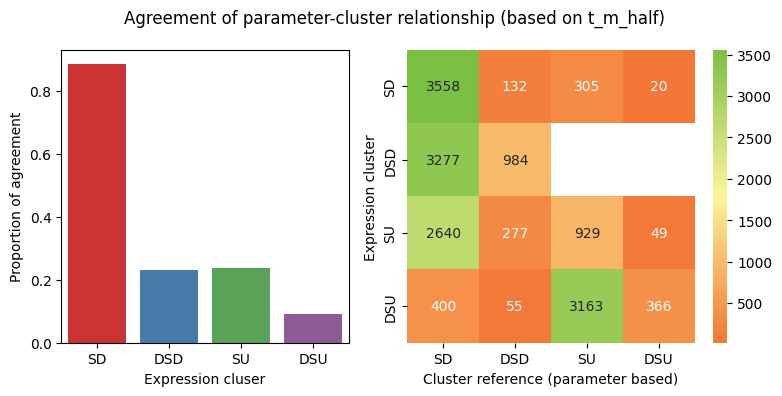

In [ ]:
# ds_params = pd.read_csv("results/results_summary/params_combined.csv")
# df = ds_params[ds_params["model"] != "Basic" ].copy()


df = ds_params_selected.copy()
df = df[df["gene_id"].isin(genes_acc)]


df["r"] = df["beta_mean"] / df["alpha_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]
df = df[df["r"] > 1e-5]

param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_reg_mean", "t_half_m", "supercluster"]].copy()

import numpy as np

zga_time = 5.0
half_life = 1.0


param_cluster["t_zga"] = param_cluster["t_zga_mean"]
param_cluster["t_reg"] = param_cluster["t_reg_mean"]

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
#param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] <= 1, "dir"] = "down"

param_cluster.loc[param_cluster["t_zga"] <= zga_time, "activation"] = "early"
param_cluster.loc[param_cluster["t_zga"] > zga_time, "activation"] = "late"

param_cluster.loc[param_cluster["t_half_m"] > half_life, "degradation"] = "late"
param_cluster.loc[param_cluster["t_half_m"] <= half_life, "degradation"] = "early"

param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["degradation"] == "early"), "cluster_ref"] = "SU"
param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["degradation"] == "late"), "cluster_ref"] = "DSU"

param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["degradation"] == "early"), "cluster_ref"] = "SD"
param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["degradation"] == "late"), "cluster_ref"] = "DSD"

param_cluster["agree"] = False
param_cluster.loc[param_cluster["supercluster"] ==  param_cluster["cluster_ref"], "agree"] = True

#param_cluster.loc[param_cluster["t_reg_mean"] < 2, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_reg_mean"] <= 4) & (param_cluster["t_zga_mean"] >= 2) , "activation"] = "zga"
#param_cluster.loc[param_cluster["t_reg_mean"] > 4, "activation"] = "late"

import seaborn as sns
import matplotlib.pyplot as plt

#res = param_cluster.groupby(["model", "supercluster"])["agree"].mean()
res = param_cluster.groupby(["supercluster"])["agree"].mean()

res_df = res.reset_index()
# columns: model, supercluster, agree

fig, ax = plt.subplots(1,2, figsize=(8, 4), width_ratios=[0.8,1])
#sns.barplot(data=res_df, x="supercluster", y="agree", hue="model", palette=mod_color_dict)
sns.barplot(data=res_df, x="supercluster", y="agree", errorbar=None, hue="supercluster", 
            palette=cluster_color_dict, order=gams_cluster_order, ax=ax[0])

ax[0].set(ylabel="Proportion of agreement", xlabel="Expression cluser")
#plt.legend(title="Model", frameon=False)
#plt.tight_layout()
#plt.savefig("results/figures/simple_parameter_cluster_relationship.png", dpi=300)

print(res_df)
res_df = param_cluster.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()
df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
df_plot = df_plot.reindex(index=gams_cluster_order, columns=gams_cluster_order)
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[1])
ax[1].set(ylabel="Expression cluster",xlabel="Cluster reference (parameter based)")

plt.suptitle("Agreement of parameter-cluster relationship (based on t_m_half" \
")")
plt.tight_layout()
plt.savefig("results/figures/simple_parameter_cluster_relationship_all_tmhalf.png", dpi=300)
plt.show()


In [59]:
FIG_PATH = "results/figures"

def plot_regulation_direction(ds_params):

    print("Plot regulation indicator r ...")

    df = ds_params[ds_params["model"] != "Basic" ].sort_values("supercluster_no")
    df["r"] = df["beta_mean"] / df["alpha_mean"]
    df = df[df["r"] > 1e-5]

    palette = sns.color_palette("Accent") 

    panels = ["Repression M-decay", "Repression Z-decay",]
    models = ["Rep_M", "Rep_Z",]

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5), sharey=True, sharex=True)

    sns.stripplot( data=df, x="r", y="supercluster", log_scale=True, hue="subcluster_no", order=gams_cluster_order,
                        dodge=True, size=3, alpha=0.7, palette=palette, ax=ax, legend=True, zorder=1)

        # ---- overlay median tick marks per supercluster ----
    sns.pointplot(data=df, x="r", y="supercluster", markers="|", markersize=40, linestyles="", hue="supercluster",
                        estimator="median", palette=cluster_color_dict, ax=ax, legend=False, zorder=3)

    ax.axvline(1, color="black", linestyle="--", linewidth=1, zorder=2)
    ax.set(title="Direction of regulation", xlabel = "indicator of regulation $r = \\beta / \\alpha$", ylabel="")

    # shared legend on the right
    sns.move_legend(ax, loc=(1.02, 0.3), frameon=False, title="Subcluster")

    plt.tight_layout()
    plt.savefig(f"{FIG_PATH}/regulation_indicator.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_regulation_direction_2(ds_params):

    print("Plot regulation indicator r ...")

    df = ds_params[ds_params["model"] != "Basic" ].sort_values("supercluster_no")
    df["r"] = df["beta_mean"] / df["alpha_mean"]
    df = df[np.isfinite(df["r"]) & (df["r"] > 1e-5)]
    df["t_half_m"] = np.log(2) / df["delta_m_mean"]

    #df.loc[(df["model"] ==  "Rep_Z"), "t_half_m"] = df["t_half_m"] + zga_time   # add 3 hours since maternal decay starts only after zga

    palette = sns.color_palette("Greys", 3) 

    marker_dict = ["o", "x", "^"]

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
    sns.violinplot( data=df, x="r", y="supercluster", log_scale=True, hue="supercluster", palette=cluster_color_dict,
                        split=False, inner = "quart", alpha=1.0, legend=False, zorder=1, ax=ax[0])

    sns.violinplot( data=df, x="t_zga_mean", y="supercluster", log_scale=True, hue="supercluster", palette=cluster_color_dict,
                        split=False, inner = "quart", alpha=1.0, legend=False, zorder=1, ax=ax[1])

    sns.violinplot( data=df, x="t_half_m", y="supercluster", log_scale=True, hue="supercluster", palette=cluster_color_dict,
                        split=False, inner = "quart", alpha=1.0, legend=True, zorder=1, ax=ax[2])
    # ---- overlay median tick marks per supercluster ----

    sns.pointplot(data=df, x="r", y="supercluster", markers=marker_dict, markersize=3, linestyles="", hue="subcluster_no",
                estimator="median", palette=palette,legend=False, zorder=3, ax=ax[0])
    
    sns.pointplot(data=df, x="t_zga_mean", y="supercluster", markers=marker_dict, markersize=3, linestyles="", hue="subcluster_no",
                estimator="median", palette=palette, legend=False, zorder=3, ax=ax[1])
    
    sns.pointplot(data=df, x="t_half_m", y="supercluster", markers=marker_dict, markersize=3, linestyles="", hue="subcluster_no",
                estimator="median", palette=palette, legend=True, zorder=3, ax=ax[2])
    
    ax[0].axvline(1, color="black", linestyle="--", linewidth=1, zorder=2)
    ax[1].axvline(5, color="black", linestyle="--", linewidth=1, zorder=2)
    ax[2].axvline(1, color="black", linestyle="--", linewidth=1, zorder=2)

    ax[0].set(title="Direction of regulation", xlabel = "$r = \\beta / \\alpha$", ylabel="")
    ax[1].set(title="Zygotic genome activation time", xlabel = "$t_{zga}$", ylabel="")
    ax[2].set(title="Maternal degradation half-life", xlabel = "$t_{m, half}$", ylabel="")

    # shared legend on the right
    sns.move_legend(ax[2], loc=(1.02, 0.15), frameon=False, title="Cluster")

    plt.tight_layout()
    plt.savefig(f"{FIG_PATH}/regulation_indicator_2.png", dpi=150, bbox_inches="tight")
    plt.show()


df = ds_params_selected.copy()
df = df[df["gene_id"].isin(genes_acc)]

print(len(df))
#plot_regulation_direction(df)
plot_regulation_direction_2(df)


NameError: name 'ds_params_selected' is not defined

In [ ]:
df = ds_params_selected.copy()
df = df[df["gene_id"].isin(genes_acc)]

df["r"] = df["beta_mean"] / df["alpha_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]

df = df[df["r"] > 1e-5]

param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_reg_mean", "t_half_m", "supercluster"]].copy()

import numpy as np

zga_time = 5.0
half_life = 1.0

param_cluster["t_zga"] = param_cluster["t_zga_mean"]
param_cluster["t_reg"] = param_cluster["t_reg_mean"]

#param_cluster.loc[(param_cluster["model"] ==  "Rep_Z"), "t_half_m"] = param_cluster["t_half_m"] + zga_time   # add 3 hours since maternal decay starts only after zga

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
#param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] <= 1, "dir"] = "down"

param_cluster.loc[param_cluster["t_zga"] <= zga_time, "activation"] = "early"
param_cluster.loc[param_cluster["t_zga"] > zga_time, "activation"] = "late"

param_cluster.loc[param_cluster["t_half_m"] > half_life, "degradation"] = "late"
param_cluster.loc[param_cluster["t_half_m"] <= half_life, "degradation"] = "early"

param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["degradation"] == "early"), "cluster_ref"] = "SU"
param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["degradation"] == "late"), "cluster_ref"] = "DSU"

param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["degradation"] == "early"), "cluster_ref"] = "SD"
param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["degradation"] == "late"), "cluster_ref"] = "DSD"

param_cluster["agree_r"] = False
param_cluster.loc[(param_cluster["supercluster"] ==  "SU") & (param_cluster["dir"] == "up"), "agree_r"] = True
param_cluster.loc[(param_cluster["supercluster"] ==  "DSU") & (param_cluster["dir"] == "up"), "agree_r"] = True
param_cluster.loc[(param_cluster["supercluster"] ==  "SD") & (param_cluster["dir"] == "down"), "agree_r"] = True
param_cluster.loc[(param_cluster["supercluster"] ==  "DSD") & (param_cluster["dir"] == "down"), "agree_r"] = True
param_cluster

param_cluster["agree_activation"] = False
param_cluster.loc[(param_cluster["supercluster"] ==  "SU") & (param_cluster["activation"] == "early"), "agree_activation"] = True
param_cluster.loc[(param_cluster["supercluster"] ==  "DSU") & (param_cluster["activation"] == "late"), "agree_activation"] = True

param_cluster["agree_degradation"] = False
param_cluster.loc[(param_cluster["supercluster"] ==  "SD") & (param_cluster["degradation"] == "early"), "agree_degradation"] = True
param_cluster.loc[(param_cluster["supercluster"] ==  "DSD") & (param_cluster["degradation"] == "late"), "agree_degradation"] = True
param_cluster

,gene_id,model,r,t_zga_mean,t_reg_mean,t_half_m,supercluster,t_zga,t_reg,dir,activation,degradation,cluster_ref,agree_r,agree_activation,agree_degradation
0,ENSDARG00000000002,Rep_M,1.785714,12.500,46.60,11.161790,DSU,12.500,46.60,up,late,late,DSU,True,True,False
1,ENSDARG00000000069,Rep_M,0.495858,3.060,22.30,2.062938,SD,3.060,22.30,down,early,late,DSD,True,False,False
2,ENSDARG00000000380,Rep_M,7.428571,1.390,64.80,1.904250,DSU,1.390,64.80,up,early,late,DSU,True,False,False
3,ENSDARG00000000394,Rep_M,0.120574,0.556,6.36,5.096670,DSD,0.556,6.36,down,early,late,DSD,True,False,True
4,ENSDARG00000000489,Rep_M,0.230583,0.914,5.24,13.974742,DSD,0.914,5.24,down,early,late,DSD,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16179,ENSDARG00000117777,Rep_Z,0.004473,3.050,4.03,0.282917,SD,3.050,4.03,down,early,early,SD,True,False,True
16180,ENSDARG00000117778,Rep_Z,0.001207,0.342,2.12,0.533190,SD,0.342,2.12,down,early,early,SD,True,False,True
16181,ENSDARG00000117792,Rep_Z,0.001326,0.719,2.07,0.877401,SD,0.719,2.07,down,early,early,SD,True,False,True
16182,ENSDARG00000117812,Rep_Z,0.643750,4.790,18.40,0.441495,SU,4.790,18.40,down,early,early,SD,False,True,False


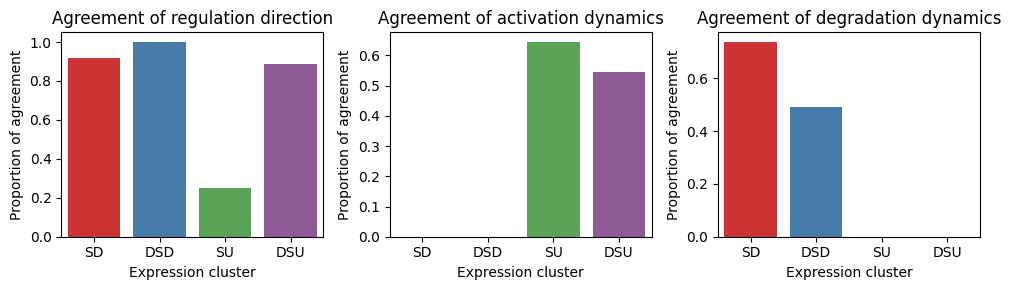

In [ ]:
param_cluster.groupby("supercluster").agree_r.mean()

fig, ax = plt.subplots(1,3, figsize=(10, 3))
sns.barplot(data=param_cluster, x="supercluster", y="agree_r", errorbar=None, hue="supercluster", 
            palette=cluster_color_dict, order=gams_cluster_order, ax=ax[0])
ax[0].set(ylabel="Proportion of agreement", xlabel="Expression cluster", title="Agreement of regulation direction")

sns.barplot(data=param_cluster, x="supercluster", y="agree_activation", errorbar=None, hue="supercluster", 
            palette=cluster_color_dict, order=gams_cluster_order, ax=ax[1])
ax[1].set(ylabel="Proportion of agreement", xlabel="Expression cluster", title="Agreement of activation dynamics")

sns.barplot(data=param_cluster, x="supercluster", y="agree_degradation", errorbar=None, hue="supercluster", 
            palette=cluster_color_dict, order=gams_cluster_order, ax=ax[2])
ax[2].set(ylabel="Proportion of agreement", xlabel="Expression cluster", title="Agreement of degradation dynamics")

plt.tight_layout()
plt.savefig("results/figures/agree_r.png", dpi=300)

In [218]:
param_cluster.groupby("supercluster").agree_degradation.mean()

supercluster
DSD    0.492138
DSU    0.000000
SD     0.736488
SU     0.000000
Name: agree_degradation, dtype: float64

## Plot gene trajectories - compare GAMS vs Model

In [131]:
## plot low expression genes
data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
mask = (data.tpm.max(dim="time", skipna=True) < 0.1).all(dim="source") 
data = data.sel(ensembl_gene_id=mask)

low_genes = data.ensembl_gene_id.values
low_genes

array(['ENSDARG00000003090', 'ENSDARG00000004598', 'ENSDARG00000007067',
       ..., 'ENSDARG00000117811', 'ENSDARG00000117819',
       'ENSDARG00000117825'], dtype=object)

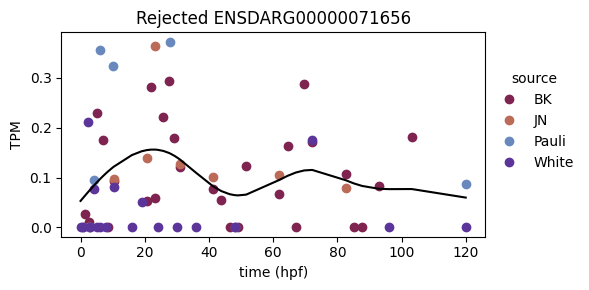

In [ ]:
gene = rejected_genes[4]
data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
traj = xr.load_dataset(f"clustering/results/{sc}_gene_trajectories_120_log.nc")


fig, ax = plt.subplots(figsize=(6,3))
for i in data.source.values:
    ax.plot(data.time, data.sel(ensembl_gene_id = gene).tpm.sel(source=i), "o", label=i, color=src_color_dict[i],)
ax.plot(traj.time, traj.sel(ensembl_gene_id=gene).trajectory, "k-")
ax.legend(title="source", frameon=False, loc=(1.01, 0.3))
ax.set(title=f"Rejected {gene}", xlabel="time (hpf)", ylabel="TPM",)
plt.tight_layout()
plt.savefig(f"figures/rejected_{gene}.png", dpi=300)
plt.show()

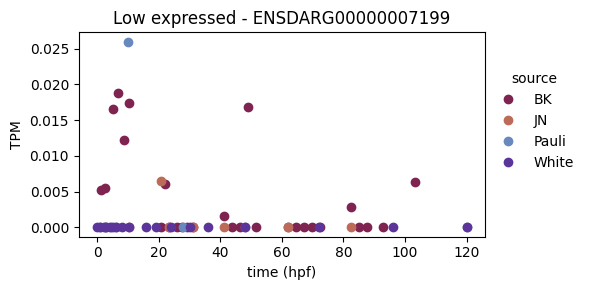

In [136]:
gene = low_genes[3]
fig, ax = plt.subplots(figsize=(6,3))
for i in data.source.values:
    ax.plot(data.time, data.sel(ensembl_gene_id = gene).tpm.sel(source=i), "o", label=i, color=src_color_dict[i],)
ax.legend(title="source", frameon=False, loc=(1.01, 0.3))
ax.set(title=f"Low expressed - {gene}", xlabel="time (hpf)", ylabel="TPM",)
plt.tight_layout()
plt.savefig(f"figures/low_expressed_{gene}.png", dpi=300)
plt.show()

In [58]:
res_joined[res_joined["status"] == "low_error"][["gene_id", "model", "spearman_rho", "NRMSE"]].sort_values("NRMSE")

,gene_id,model,spearman_rho,NRMSE
87690,ENSDARG00000116152,M-decay,0.109731,0.011011
28506,ENSDARG00000116152,Basic,0.037864,0.012609
52825,ENSDARG00000090469,Z-decay,0.392880,0.051719
82178,ENSDARG00000090469,M-decay,0.392880,0.051722
16100,ENSDARG00000098752,Basic,0.414430,0.064724
...,...,...,...,...
22864,ENSDARG00000095006,Basic,0.419821,0.299963
22676,ENSDARG00000092615,Basic,-0.016376,0.299968
28284,ENSDARG00000114323,Basic,-0.112911,0.299987
3460,ENSDARG00000021882,Basic,0.386987,0.299989


In [177]:
res_joined[(res_joined["subcluster"] == "N/A")][["gene_id", "model", "spearman_rho", "NRMSE", "status"]].status.value_counts()

status
poor_fit    291
pattern      11
non_con       4
Name: count, dtype: int64

In [201]:
res_plot[(res_plot["supercluster"] == "N/A") & (res_plot["status"] == "fully_accepted")]

res_plot[res_plot["gene_id"].isin(genes)].sort_values("gene_id")


,gene_id,model,status,NRMSE,spearman_rho,supercluster,subcluster
54254,ENSDARG00000000606,Z-decay,non_con,0.201562,0.826843,N/A,N/A
25494,ENSDARG00000000606,Basic,fully_accepted,0.232887,0.742905,N/A,N/A
83550,ENSDARG00000000606,M-decay,non_con,0.203703,0.826939,N/A,N/A
200,ENSDARG00000002394,Basic,fully_accepted,0.249310,0.857758,N/A,N/A
58817,ENSDARG00000002394,M-decay,non_con,0.140739,0.857758,N/A,N/A
...,...,...,...,...,...,...,...
86606,ENSDARG00000117707,M-decay,non_con,0.232019,0.881318,N/A,N/A
26052,ENSDARG00000117707,Basic,fully_accepted,0.229364,0.881318,N/A,N/A
25259,ENSDARG00000117735,Basic,fully_accepted,0.192089,0.666475,N/A,N/A
86655,ENSDARG00000117735,M-decay,non_con,0.132599,0.666475,N/A,N/A


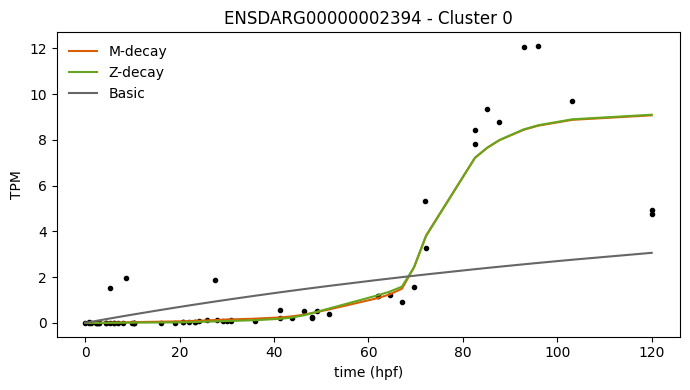

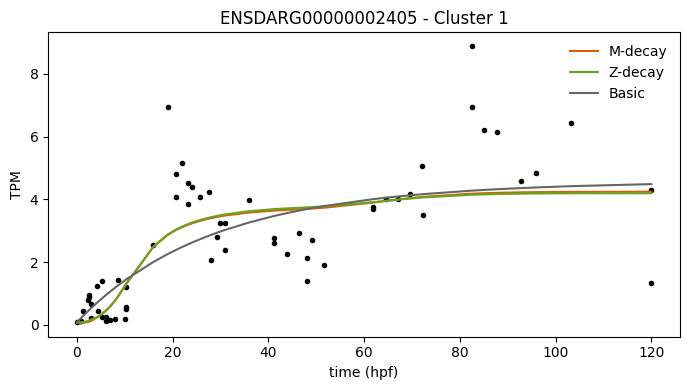

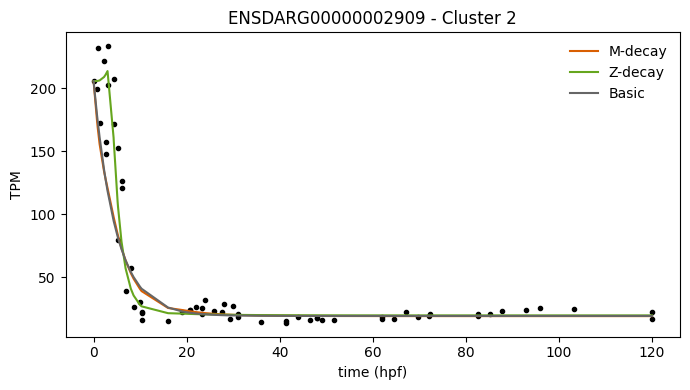

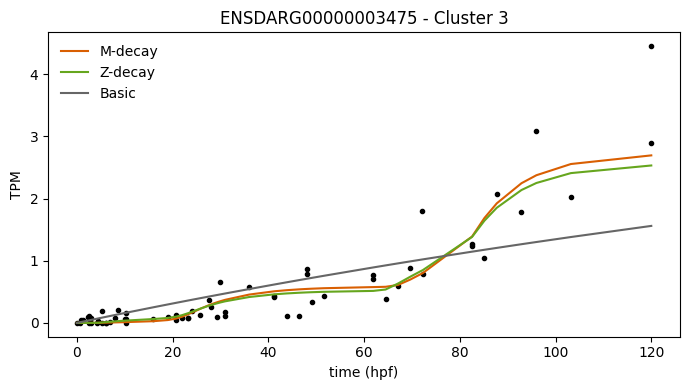

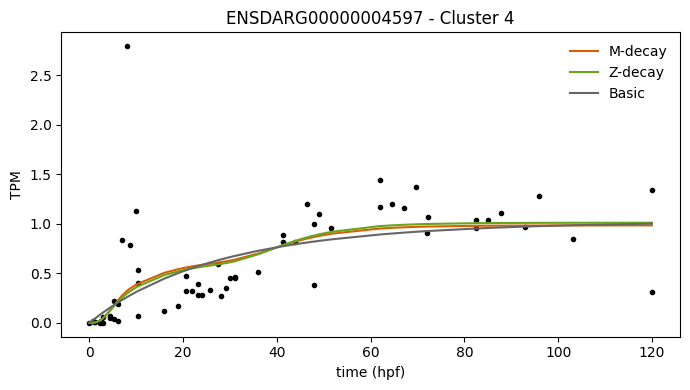

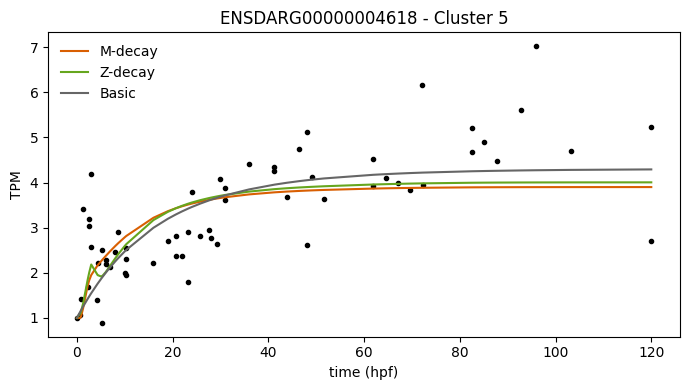

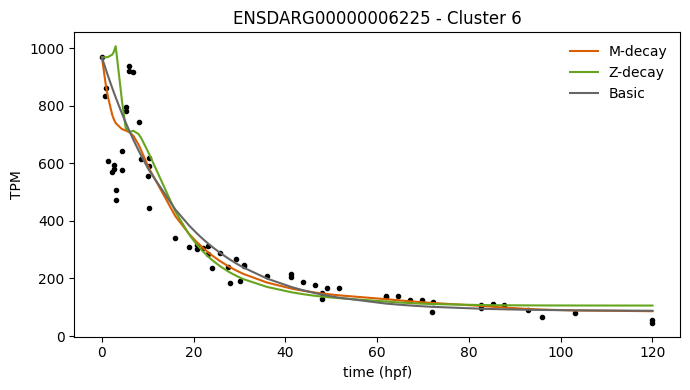

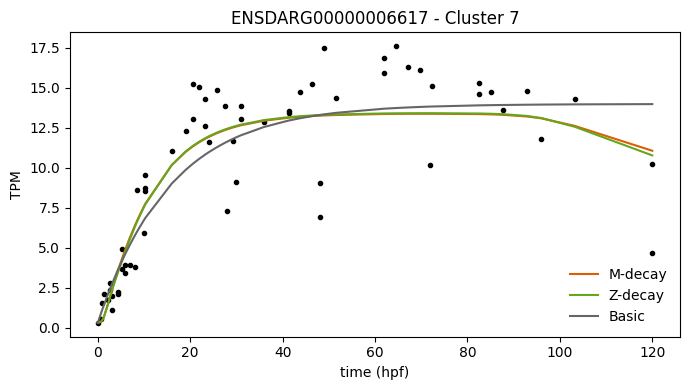

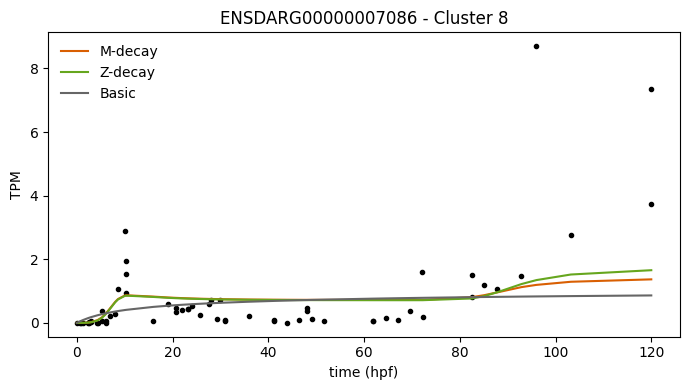

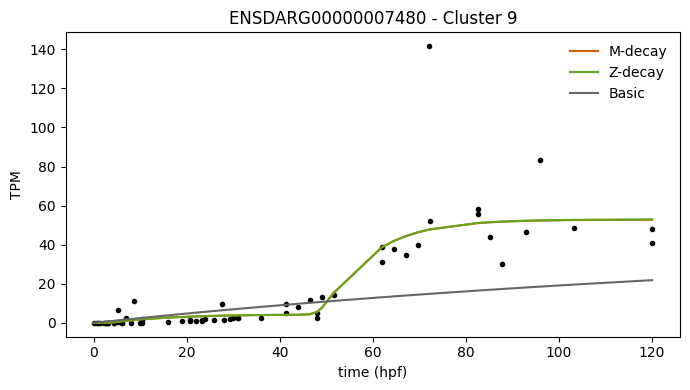

In [198]:
# top cluster genes
# genes = ["ENSDARG00000110015",
#          "ENSDARG00000057323",
#          "ENSDARG00000097353",
#          "ENSDARG00000092161",
#          ]
genes = res_plot[(res_plot["supercluster"] == "N/A") & (res_plot["status"] == "fully_accepted")].gene_id.values
#genes = ["ENSDARG00000092615"]

for i, gene in enumerate(genes[:10]):
    data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id = gene)
    fit_M = xr.load_dataset("results/results_summary/Rep_M/simulation_results.nc").sel(ensembl_gene_id = gene).mean(dim="source")
    fit_Z = xr.load_dataset("results/results_summary/Rep_Z/simulation_results.nc").sel(ensembl_gene_id = gene).mean(dim="source")
    fit_B = xr.load_dataset("results/results_summary/Basic/simulation_results.nc").sel(ensembl_gene_id = gene).mean(dim="source")


    fig, ax = plt.subplots(figsize=(7,4))

    ax.plot(data.time, data.tpm, ".", color="k")
    ax.plot(fit_M.time, fit_M.y, ls="-", c=mod_color_dict["M-decay"], label="M-decay")
    ax.plot(fit_Z.time, fit_Z.y, ls="-", c=mod_color_dict["Z-decay"], label="Z-decay")
    ax.plot(fit_B.time, fit_B.y, ls="-", c=mod_color_dict["Basic"], label="Basic")

    ax.set(title= f"{gene} - Cluster {i}", xlabel="time (hpf)", ylabel="TPM")
    plt.legend(frameon=False)
    plt.tight_layout()
    #plt.savefig(f"figures/cluster_center_{gene}.png", dpi=300)
    plt.show()

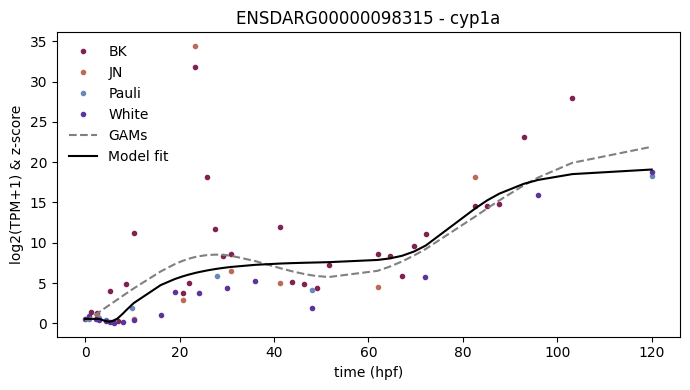

In [ ]:
gene = "ENSDARG00000098315"
name = "cyp1a"

data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id = gene)
gams =xr.load_dataset(f"clustering/results/{sc}_gene_trajectories_120_log.nc").trajectory.sel(ensembl_gene_id = gene)
fit = xr.load_dataset("clustering/joint_simulation_results.nc").sel(ensembl_gene_id = gene)

fig, ax = plt.subplots(figsize=(7,4))
for i in data.source.values:
    ax.plot(data.time, data.tpm.sel(source=i), ".", label=i, color=src_color_dict[i])
ax.plot(gams.time, gams, ls="--", c="grey", label="GAMs")
ax.plot(fit.time, fit.tpm, ls="-", c="k", label="Model fit")

ax.set(title= f"{gene} - {name}", xlabel="time (hpf)", ylabel="TPM")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"figures/compare_fits_transf_{gene}.png", dpi=300)
plt.show()


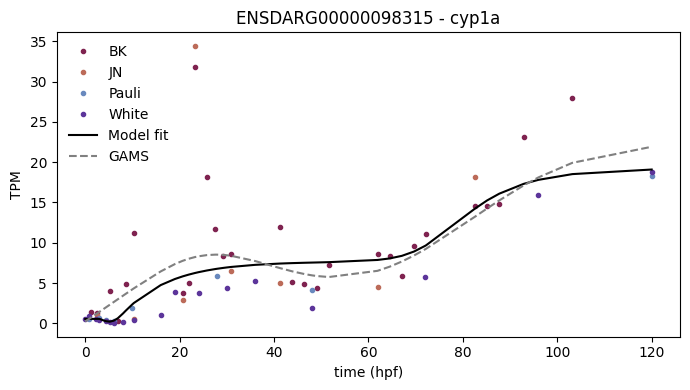

In [ ]:
gene = "ENSDARG00000098315"
name = "cyp1a"

fit = xr.load_dataset("clustering/joint_simulation_results.nc").sel(ensembl_gene_id = gene) # model fit
data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id = gene) # observed data
gams = xr.load_dataset(f"clustering/results/{sc}_gene_trajectories_120_log.nc").trajectory.sel(ensembl_gene_id = gene)

# plot
fig, ax = plt.subplots(figsize=(7,4))
for i in data.source.values:
    ax.plot(data.sel(source=i).time, data.tpm.sel(source=i), ".", label=i, color=src_color_dict[i])
ax.plot(fit.time, fit.tpm, ls="-", c="k", label="Model fit")
ax.plot(gams.time, gams, ls="--", c="gray", label="GAMS")

ax.set(title= f"{gene} - {name}", xlabel="time (hpf)", ylabel="TPM")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"figures/compare_fits_{gene}.png", dpi=300)
plt.show()


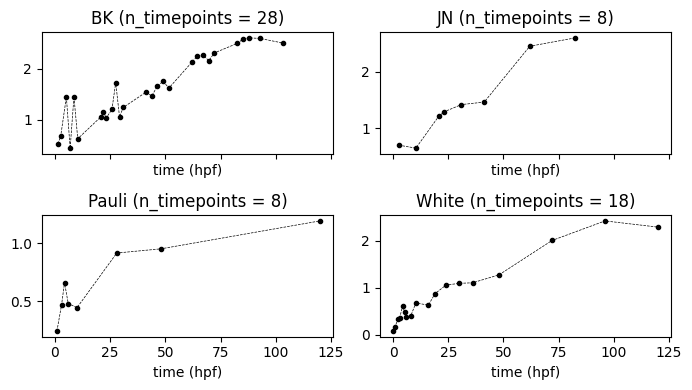

In [3]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

# t_not = [5.16, 8.6, 27.52, 41.28]
# mask = ~ds0.time.isin(t_not)
# ds0 = ds0.sel(time=mask)

fig, ax = plt.subplots(2,2, figsize=(7, 4), sharex=True)
ax = ax.flatten()

for x, src in enumerate(ds0.source.values):
    ds = ds0.sel(source=src)
    ds = ds.dropna(dim="time", how="all", subset=["tpm"])
    #print(np.isnan(ds["tpm"].values).sum())
    ax[x].plot(ds.time, ds.tpm.median(dim="ensembl_gene_id"), ".--", c="k", lw=0.5)
    ax[x].set(title=f"{src} (n_timepoints = {len(ds.time)})", xlabel="time (hpf)")
plt.tight_layout()